# Installing Dependencies

The HMDA 2024 LAR file is ~665MB zipped. We use **gdown** to pull it directly
from Google Drive and duckdb to query it efficiently without loading all 99
columns into pandas memory at once.

In [ ]:
# Install required libraries
# gdown: download files from Google Drive
# duckdb: fast in-process SQL engine used to query the large HMDA file
#         without loading all 99 columns into memory at once
%pip install solas-ai
%pip install -q gdown duckdb
%pip install pandas numpy matplotlib scikit-learn lifelines

import gdown        # Google Drive downloader
import zipfile      # unzip the downloaded archive
import duckdb       # SQL query engine for large file handling
import os           # file path oper ations
import pandas as pd # dataframe manipulation
import warnings
warnings.filterwarnings('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.5 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=291027812d8061e51cb8922cc7395ba9384c65066d94af9fea33c7855ebc0240
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec40

This cell installs and imports the main libraries needed for the analysis.

# Downloading HMDA Data from Public Google Drive

The 2024 HMDA Loan Application Register (LAR) is downloaded from a shared
Google Drive link. The file is pipe-delimited (`|`) and contains one row per
loan application across all covered institutions nationally.
Download takes approximately 1 minute.

In [ ]:
# Download HMDA 2024 LAR from Google Drive
# Source: https://ffiec.cfpb.gov/data-publication/dynamic-national-loan-level-dataset/2024
file_id = "1TwuI1Fph0wSY60l6AqjHgvzSyuho2IpE"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "data.zip", quiet=False)

# Unzip to local Colab storage
# Extracting locally is faster than reading repeatedly from Drive
with zipfile.ZipFile("data.zip", "r") as zip_ref:
    zip_ref.extractall("data")

# Locate the extracted .txt file
# The zip contains a single pipe-delimited .txt file
hmda_file = None
for root, dirs, files in os.walk("data"):
    for f in files:
        if f.endswith(".txt"):
            hmda_file = os.path.join(root, f)

print(f"Using file: {hmda_file}")

Downloading...
From (original): https://drive.google.com/uc?id=1TwuI1Fph0wSY60l6AqjHgvzSyuho2IpE
From (redirected): https://drive.google.com/uc?id=1TwuI1Fph0wSY60l6AqjHgvzSyuho2IpE&confirm=t&uuid=0518ca1a-d319-4f4d-a8cb-880c08028373
To: /content/data.zip
100%|██████████| 665M/665M [00:06<00:00, 110MB/s] 


Using file: data/2024_lar.txt


This cell downloads the 2024 HMDA loan-level dataset from Google Drive, unzips it into the local Colab environment, and locates the extracted `.txt` file.

# Checking the Schema

Before selecting features we inspect the full column list. The HMDA LAR has
99 columns covering loan characteristics, applicant demographics, geographic
identifiers, and post-decision fields. We use DuckDB to load only a 10,000
row sample for schema inspection without loading the full dataset into memory.

In [ ]:
# Connect DuckDB in-process
# DuckDB reads the pipe-delimited file directly via SQL
# all_varchar=True reads every column as string to avoid type inference errors
# on mixed-format fields like debt_to_income_ratio ('30%-<36%', '42', 'Exempt')
con = duckdb.connect()

# Load 10,000 rows for schema inspection only
df = con.execute(f"""
SELECT *
FROM read_csv_auto(
    '{hmda_file}',
    delim='|',
    all_varchar=True
)
LIMIT 10000
""").fetchdf()

print(f"Loaded {len(df):,} rows and {len(df.columns)} columns.")

# Print all column names to inform feature selection
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"{i:3}. {col}")

Loaded 10,000 rows and 99 columns.

All columns:
  0. activity_year
  1. lei
  2. derived_msa_md
  3. state_code
  4. county_code
  5. census_tract
  6. conforming_loan_limit
  7. derived_loan_product_type
  8. derived_dwelling_category
  9. derived_ethnicity
 10. derived_race
 11. derived_sex
 12. action_taken
 13. purchaser_type
 14. preapproval
 15. loan_type
 16. loan_purpose
 17. lien_status
 18. reverse_mortgage
 19. open_end_line_of_credit
 20. business_or_commercial_purpose
 21. loan_amount
 22. combined_loan_to_value_ratio
 23. interest_rate
 24. rate_spread
 25. hoepa_status
 26. total_loan_costs
 27. total_points_and_fees
 28. origination_charges
 29. discount_points
 30. lender_credits
 31. loan_term
 32. prepayment_penalty_term
 33. intro_rate_period
 34. negative_amortization
 35. interest_only_payment
 36. balloon_payment
 37. other_nonamortizing_features
 38. property_value
 39. construction_method
 40. occupancy_type
 41. manufactured_home_secured_property_type
 42. ma

This cell connects to DuckDB and reads a small 10,000-row sample from the full HMDA file. All columns are loaded as text to avoid formatting issues in mixed fields such as debt-to-income ratio. The output confirms that the sample has 10,000 rows and 99 columns, then lists all available column names so we can choose the correct features for modeling.

## Building the Modeling Dataset

We select features using DuckDB SQL directly from the raw file. This avoids
loading all 99 columns into memory. Feature selection follows three principles:

1. **No data leakage:** post-decision fields (denial_reason, origination_charges)
   are excluded because they are only known after the lending decision is made.
2. **Include underwriting signals:** loan details before approval decision, applicant financials,
   and census tract context available at time of application.
3. **Include protected attributes:** race, ethnicity, sex, and age are included
   for analysis but represent a governance risk if used directly as model features.

We load up rows to capture a representative national sample.

In [ ]:
# Query selected columns from HMDA file via DuckDB
# Only the columns we need are loaded avoids RAM crash from loading all 99
#
# action_taken: target variable (values 1-8, filtered to 1 and 3 below)
# Loan characteristics: amount, property value, reverse mortage, type, purpose, DTI
# Applicant demographics: income, race (protected), ethnicity (protected), sex (protected), age (protected)
# Geography: derived_msa_md, ffiec_msa_md_median_family_income, state_code (proxy)
#
# WHERE action_taken IS NOT NULL removes rows with missing target
df_model = con.execute(f"""
SELECT
    action_taken,
    loan_purpose,
    state_code,
    property_value,
    reverse_mortgage,
    preapproval,
    submission_of_application,
    business_or_commercial_purpose,
    occupancy_type,
    derived_dwelling_category,
    income,
    debt_to_income_ratio,
    derived_ethnicity,
    derived_race,
    derived_sex,
    applicant_age,
    tract_population,
    construction_method,
    aus_1,
    ffiec_msa_md_median_family_income,

     CASE
        WHEN action_taken IN ('1', '2') THEN 1
        WHEN action_taken = '3' THEN 0
     END AS approved

FROM read_csv_auto(
    '{hmda_file}',
    delim='|',
    all_varchar=True
)
WHERE action_taken IS NOT NULL
AND action_taken IN ('1', '2', '3')
AND NOT (
    action_taken IN ('Exempt','NA','NaN','','8888') OR
    loan_purpose IN ('Exempt','NA','NaN','','8888') OR
    state_code IN ('Exempt','NA','NaN','','8888') OR
    property_value IN ('Exempt','NA','NaN','','8888') OR
    reverse_mortgage IN ('Exempt','NA','NaN','','8888') OR
    preapproval IN ('Exempt','NA','NaN','','8888') OR
    submission_of_application IN ('Exempt','NA','NaN','','8888') OR
    business_or_commercial_purpose IN ('Exempt','NA','NaN','','8888') OR
    occupancy_type IN ('Exempt','NA','NaN','','8888') OR
    derived_dwelling_category IN ('Exempt','NA','NaN','','8888') OR
    income IN ('Exempt','NA','NaN','','8888') OR
    debt_to_income_ratio IN ('Exempt','NA','NaN','','8888') OR
    derived_ethnicity IN ('Exempt','NA','NaN','','8888') OR
    derived_race IN ('Exempt','NA','NaN','','8888') OR
    derived_sex IN ('Exempt','NA','NaN','','8888') OR
    applicant_age IN ('Exempt','NA','NaN','','8888') OR
    tract_population IN ('Exempt','NA','NaN','','8888') OR
    construction_method IN ('Exempt','NA','NaN','','8888') OR
    aus_1 IN ('Exempt','NA','NaN','','8888') OR
    ffiec_msa_md_median_family_income IN ('Exempt','NA','NaN','','8888')
)
AND derived_sex NOT IN ('Joint', 'Sex Not Available')
""").df()
print(df_model.shape)
df_model.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(4319338, 21)


,action_taken,loan_purpose,state_code,property_value,reverse_mortgage,preapproval,submission_of_application,business_or_commercial_purpose,occupancy_type,derived_dwelling_category,...,debt_to_income_ratio,derived_ethnicity,derived_race,derived_sex,applicant_age,tract_population,construction_method,aus_1,ffiec_msa_md_median_family_income,approved
0,1,1,IN,285000,2,2,1,2,1,Single Family (1-4 Units):Manufactured,...,30%-<36%,Not Hispanic or Latino,White,Male,25-34,2528,2,1,81800,1
1,1,32,FL,425000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,50%-60%,Hispanic or Latino,White,Female,45-54,7516,1,1,90400,1
2,3,1,GA,185000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,50%-60%,Not Hispanic or Latino,Black or African American,Female,45-54,3329,1,1,100900,0
3,1,1,NJ,575000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,49,Not Hispanic or Latino,Black or African American,Male,55-64,5513,1,6,117400,1
4,1,1,TX,455000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,46,Not Hispanic or Latino,Asian,Male,35-44,2144,1,2,110300,1


This cell uses DuckDB to load only the HMDA columns needed for modeling instead of loading the full 99-column file. It keeps relevant loan, applicant, demographic, and geographic variables, removes invalid or exempt values, and creates a binary target variable called `approved`, where approved or originated applications are coded as 1 and denied applications are coded as 0.

## Analyzing Target Variable Distribution

Before filtering we inspect the full distribution of action_taken to understand
how many applications fall into each outcome. Values 1-8 cover the full application
lifecycle. We keep only originated (1) and denied (3) for a clean binary problem.

In [ ]:
# Inspect action_taken distribution before filtering
# action_taken values:
# 1 = Loan originated          -- keep, label = 1 (approved)
# 2 = Approved but not accepted -- excluded (ambiguous, applicant declined)
# 3 = Application denied        -- keep, label = 0 (denied)
# 4 = Withdrawn by applicant    -- excluded (no lender decision made)
# 5 = File closed incomplete    -- excluded (no lender decision made)
# 6 = Purchased loan            -- excluded (post-origination, not an application)
# 7 = Preapproval denied        -- excluded (preapproval, not a full application)
# 8 = Preapproval approved      -- excluded (preapproval, not a full application)
df_model['action_taken'].value_counts(dropna=False)

,count
action_taken,
1,3029003
3,1113020
2,177315


This cell reviews the distribution of `action_taken` before final modeling. The results show that most applications were originated, followed by denied applications, while a smaller group was approved but not accepted. This step helps confirm how many observations are available for each loan decision category before focusing on the binary approval outcome.

## Creating Binary Target Variable (Approved vs Denied)

We filter to action_taken = 1 (originated), action_taken = 2, and action_taken = 3 (denied) only.
This gives a clean binary classification problem -- did the lender make a
favorable (approved) or unfavorable (denied) decision?

Note: action_taken values are strings because we used all_varchar=True
in DuckDB, so we map **'1'**, **'2'**, and **'3'** rather than integers.

In [ ]:
# Confirm label distribution -- expect significant imbalance (approvals >> denials)
df_model['approved'].value_counts()

,count
approved,
1,3206318
0,1113020


This cell checks the distribution of the final `approved` target variable. The output shows that approved applications are much more common than denied applications, which means the dataset is imbalanced. This is important to keep in mind when evaluating the model because accuracy alone may not fully reflect performance.

## Merging Ethnicity and Race Columns

In [ ]:
#Merge the columns, then clean columns. First, find out what each variable looks like.
print("\nethnicity categories:")
print(df_model['derived_ethnicity'].unique())

print("\nrace categories:")
print(df_model['derived_race'].unique())


ethnicity categories:
['Not Hispanic or Latino' 'Hispanic or Latino' 'Ethnicity Not Available'
 'Joint' 'Free Form Text Only']

race categories:
['White' 'Black or African American' 'Asian' 'Race Not Available'
 'American Indian or Alaska Native' 'Joint'
 'Native Hawaiian or Other Pacific Islander' '2 or more minority races'
 'Free Form Text Only']


This cell checks the unique values in the race and ethnicity columns before cleaning. This helps identify which categories are usable for subgroup analysis and which values, such as unavailable, joint, or free-form responses, may need to be filtered or handled consistently before modeling.

In [ ]:
df_model['race'] = df_model['derived_race']

df_model.loc[
    (
        (df_model['derived_race'] == "White") |
        (df_model['derived_race'] == "Race Not Available")
    ) &
    (df_model['derived_ethnicity'] == "Hispanic or Latino"),
    'race'
] = "Hispanic or Latino"

df_model.loc[df_model['race'] == "White", 'race'] = "White (Non-Hispanic)"

drop_vals = [
    "2 or more minority races",
    "Free Form Text Only",
    "Joint",
    "Race Not Available"
]

mask = ~df_model['race'].isin(drop_vals)

df_model = df_model.loc[mask].copy()

print("\nrace categories:")
print(df_model['race'].unique())
print("\nrace counts:")
print(df_model['race'].value_counts())


race categories:
['White (Non-Hispanic)' 'Hispanic or Latino' 'Black or African American'
 'Asian' 'American Indian or Alaska Native'
 'Native Hawaiian or Other Pacific Islander']

race counts:
race
White (Non-Hispanic)                         2446879
Hispanic or Latino                            609150
Black or African American                     526506
Asian                                         319323
American Indian or Alaska Native               46767
Native Hawaiian or Other Pacific Islander      13839
Name: count, dtype: int64


This cell creates a simplified `race` variable for subgroup analysis. Hispanic or Latino applicants are grouped into their own category, White applicants are labeled as White Non-Hispanic, and unclear categories such as joint, unavailable, free-form, or multiple minority races are removed. The output confirms the final race groups and their counts.

## Converting Numeric Columns and Final Cleanup for Model Prediction

Several continuous fields were loaded as strings because of **all_varchar=True** in DuckDB. We coerce these to numeric using **errors='coerce'**, which converts any remaining non-standard strings to NaN. We then drop rows where conversion failed, removing any residual non-standard values not caught earlier.

In [ ]:
#Map debt to income ratios to reflect numeric values
dti_map = {
    '<20%': 0.15,
    '20%-<30%': 0.25,
    '30%-<36%': 0.33,
    '36': 0.36,
    '37': 0.37,
    '38': 0.38,
    '39': 0.39,
    '40': 0.40,
    '41': 0.41,
    '42': 0.42,
    '43': 0.43,
    '44': 0.44,
    '45': 0.45,
    '46': 0.46,
    '47': 0.47,
    '48': 0.48,
    '49': 0.49,
    '50%-60%': 0.55,
    '>60%': 0.65
}

df_model['debt_to_income_ratio'] = df_model['debt_to_income_ratio'].map(dti_map)

# Define category order for 'derived_race' with 'White' as the reference
race_categories = ['White (Non-Hispanic)', 'Black or African American', 'Asian', 'American Indian or Alaska Native', 'Native Hawaiian or Other Pacific Islander', 'Hispanic or Latino']
df_model['race'] = df_model['race'].astype(pd.CategoricalDtype(categories=race_categories, ordered=True))

# Define category order for 'derived_sex' with 'Male' as the reference
sex_categories = ['Male', 'Female']
df_model['sex'] = df_model['derived_sex'].astype(pd.CategoricalDtype(categories=sex_categories, ordered=True))


#Step 2: The variables involved are selected and categorized
numeric_cols = [
    'income',                              # applicant gross annual income (thousands)
    'property_value',                      # The value of the property securing the covered loan, or, in the case of an application, proposed to secure the covered loan, relied on in making the credit decision
    'debt_to_income_ratio',                # the ratio, as a percentage, of the applicant's or borrower's total monthly debt to the total monthly income relied on in making the credit decision
    'ffiec_msa_md_median_family_income',   #FFIEC Median family income in dollars for the MSA/MD in which the tract is located

]

categorical_cols = [
    'loan_purpose',                   # The purpose of the covered loan or application
    'reverse_mortgage',               # whether the covered loan or application is for a reverse mortage (binary indicator)
    'submission_of_application',      # Whether the applicant or borrower submitted the application directly to the financial institution (binary indicator)
    'business_or_commercial_purpose', # Whether the covered loan or application is primarily for a business or commercial purpose
    'occupancy_type',                 # Occupancy Type for the dwelling: primary, second, investment property
    'construction_method'             # Construction method for the dwelling
]

protected_attrs = [
    'race',               # PROTECTED ATTRIBUTE -- governance risk if used as feature
    'sex',                # PROTECTED ATTRIBUTE -- governance risk if used as feature
    'applicant_age',
    'state_code'
]

#Step 3: clean data
for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

for col in categorical_cols:
    df_model[col] = df_model[col].astype('category')

# Drop rows where numeric conversion failed
# Any row still containing NaN had a non-standard value not caught earlier
model_features = numeric_cols + categorical_cols
df_model = df_model.dropna(subset=model_features)

print(df_model.shape)
df_model.head()

(3962464, 23)


,action_taken,loan_purpose,state_code,property_value,reverse_mortgage,preapproval,submission_of_application,business_or_commercial_purpose,occupancy_type,derived_dwelling_category,...,derived_race,derived_sex,applicant_age,tract_population,construction_method,aus_1,ffiec_msa_md_median_family_income,approved,race,sex
0,1,1,IN,285000,2,2,1,2,1,Single Family (1-4 Units):Manufactured,...,White,Male,25-34,2528,2,1,81800,1,White (Non-Hispanic),Male
1,1,32,FL,425000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,White,Female,45-54,7516,1,1,90400,1,Hispanic or Latino,Female
2,3,1,GA,185000,2,2,1,2,1,Single Family (1-4 Units):Site-Built,...,Black or African American,Female,45-54,3329,1,1,100900,0,Black or African American,Female
3,1,1,NJ,575000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,Black or African American,Male,55-64,5513,1,6,117400,1,Black or African American,Male
4,1,1,TX,455000,2,2,2,2,1,Single Family (1-4 Units):Site-Built,...,Asian,Male,35-44,2144,1,2,110300,1,Asian,Male


This cell converts the debt-to-income ratio into numeric values, creates ordered categories for race and sex, and separates the model inputs into numeric, categorical, and protected-attribute groups. It then converts numeric columns into usable number formats, converts categorical predictors into category types, and drops rows with missing model features so the final dataset is ready for training.

## Splitting Data into Training and Testing Sets

We use an 80/20 train/test split with **random_state=42** for reproducibility.
The test set is held out entirely and used only for final model evaluation.

Given the class imbalance (approvals >> denials), we use **stratify=y** to ensure both splits have the same approval rate, preventing the model from training on a different class distribution than it is evaluated on

In [ ]:
from sklearn.model_selection import train_test_split

# Build feature matrix X and target vector y
# Removed 'race', 'sex' from drop list to include them in the model
X = df_model.drop(columns=['approved', 'action_taken', 'race', 'sex', 'applicant_age', 'state_code'])
y = df_model['approved']

# Train/test split -- 80% train, 20% test
# random_state=42 ensures reproducibility across runs
# Consider stratify=y given class imbalance (approvals >> denials)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(3169971, 17) (792493, 17)


This cell separates the predictors from the target variable and removes protected attributes such as race, sex, age, and state from the model features. The data is then split into training and testing sets using an 80/20 split. Stratification is applied so the approval and denial proportions stay similar in both sets despite the class imbalance.

In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

approved
1    2358796
0     811175
Name: count, dtype: int64
approved
1    589699
0    202794
Name: count, dtype: int64


This cell checks the approval and denial counts in both the training and testing sets. The distributions are similar across the two splits, confirming that stratification preserved the original class balance and that both sets contain enough approved and denied cases for model evaluation.

In [ ]:
#See how many observations are allocated to different race categories
df_model["race"].value_counts()

,count
race,
White (Non-Hispanic),2446879
Hispanic or Latino,609150
Black or African American,526506
Asian,319323
American Indian or Alaska Native,46767
Native Hawaiian or Other Pacific Islander,13839


This cell reviews how many observations are available for each race group after cleaning. The dataset is heavily concentrated among White Non-Hispanic applicants, while smaller groups such as American Indian or Alaska Native and Native Hawaiian or Other Pacific Islander have much fewer observations. This imbalance matters because model performance and fairness metrics may be less stable for smaller groups.

In [ ]:
#Using the counts above, figure out the percentage of the observations
total_applicants = len(df_model)

print("White applicants: %.2f%%" % (len(df_model[df_model['race'] == 'White (Non-Hispanic)']) / total_applicants * 100))
print("Hispanic or Latino applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Hispanic or Latino']) / total_applicants * 100))
print("Black or African American applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Black or African American']) / total_applicants * 100))
print("Asian applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Asian']) / total_applicants * 100))
print("American Indian or Alaska Native applicants: %.2f%%" % (len(df_model[df_model['race'] == 'American Indian or Alaska Native']) / total_applicants * 100))
print("Native Hawaiian or Other Pacific Islander applicants: %.2f%%" % (len(df_model[df_model['race'] == 'Native Hawaiian or Other Pacific Islander']) / total_applicants * 100))

White applicants: 61.75%
Hispanic or Latino applicants: 15.37%
Black or African American applicants: 13.29%
Asian applicants: 8.06%
American Indian or Alaska Native applicants: 1.18%
Native Hawaiian or Other Pacific Islander applicants: 0.35%


This cell converts the race group counts into percentages of the full cleaned dataset. White Non-Hispanic applicants make up the majority of the sample at 61.75%, followed by Hispanic or Latino applicants at 15.37%, Black applicants at 13.29%, and Asian applicants at 8.06%. The American Indian or Alaska Native and Native Hawaiian or Other Pacific Islander groups are very small, which means fairness results for these groups should be interpreted carefully because small sample sizes can make subgroup metrics less stable.

In [ ]:
#See how many observations are allocated to different sex categories
df_model["sex"].value_counts()

,count
sex,
Male,2364883
Female,1597581


This cell reviews the number of observations by sex after cleaning. Male applicants represent a larger share of the dataset than female applicants, but both groups still have large sample sizes. This means sex-based subgroup evaluation should be more stable than the smaller race-group evaluations, although the difference in representation should still be considered when interpreting fairness results.

In [ ]:
#Using the counts above, figure out the percentage of the observations
total_applicants = len(df_model)

print("Male applicants: %.2f%%" % (len(df_model[df_model['sex'] == 'Male']) / total_applicants * 100))
print("Female applicants: %.2f%%" % (len(df_model[df_model['sex'] == 'Female']) / total_applicants * 100))

Male applicants: 59.68%
Female applicants: 40.32%


This cell converts the sex group counts into percentages of the cleaned dataset. Male applicants account for 59.68% of the sample, while female applicants account for 40.32%. The split is not perfectly balanced, but both groups are large enough to support meaningful subgroup performance and fairness comparisons.

In [ ]:
#Construct a crosstab that shows the allocation of observations between sex and race
pd.crosstab(df_model['sex'], df_model['race'])

race,White (Non-Hispanic),Black or African American,Asian,American Indian or Alaska Native,Native Hawaiian or Other Pacific Islander,Hispanic or Latino
sex,,,,,,
Male,1486333,245815,212723,28494,8778,382740
Female,960546,280691,106600,18273,5061,226410


This cell creates a crosstab to show how observations are distributed across both race and sex. The largest intersection group is White Non-Hispanic male applicants, while the smallest groups are Native Hawaiian or Other Pacific Islander applicants by sex. This helps identify which subgroup comparisons are well supported by sample size and which ones should be interpreted more carefully because of limited representation.

# Building Model

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate numeric and categorical columns
X_train_numeric = X_train[numeric_cols]
X_train_categorical = X_train[categorical_cols]
X_test_numeric = X_test[numeric_cols]
X_test_categorical = X_test[categorical_cols]

# Initialize and apply StandardScaler to numeric features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_numeric), index=X_train_numeric.index, columns=X_train_numeric.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_numeric), index=X_test_numeric.index, columns=X_test_numeric.columns)

# Initialize and apply OneHotEncoder to categorical features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = pd.DataFrame(encoder.fit_transform(X_train_categorical), index=X_train_categorical.index, columns=encoder.get_feature_names_out(categorical_cols))
X_test_encoded = pd.DataFrame(encoder.transform(X_test_categorical), index=X_test_categorical.index, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenate scaled numeric and encoded categorical features
X_train = pd.concat([X_train_scaled, X_train_encoded], axis=1)
X_test = pd.concat([X_test_scaled, X_test_encoded], axis=1)

print(X_train.shape, X_test.shape)
print(X_train.head())

(3169971, 24) (792493, 24)
           income  property_value  debt_to_income_ratio  \
2717097 -0.006959       -0.068168             -0.660900   
1239432 -0.006452       -0.046543              1.091878   
4307695 -0.003665       -0.057356             -0.660900   
3296596 -0.008902       -0.107814              1.888595   
1657045 -0.008649       -0.089793              0.454504   

         ffiec_msa_md_median_family_income  loan_purpose_1  loan_purpose_2  \
2717097                          -1.001540             0.0             0.0   
1239432                          -0.880334             1.0             0.0   
4307695                          -0.805745             0.0             0.0   
3296596                          -1.640207             1.0             0.0   
1657045                          -0.926952             0.0             1.0   

         loan_purpose_31  loan_purpose_32  loan_purpose_4  loan_purpose_5  \
2717097              0.0              1.0             0.0             0.

This cell prepares the training and testing features for the machine learning model. Numeric variables are standardized so they are on a comparable scale, while categorical variables are converted into one-hot encoded columns. After preprocessing, the final training and testing matrices contain 24 model-ready features. This step is important because the model needs all predictors in numeric format before training.

## Did We See This Bias in Our Model?

We can find this out by comparing approval decisions across racial groups.

First, we build the pipeline to include both a logistic model and a gradient boosting classisifer model (for SHAP analysis later). Then, we can evaluate the AUC, FPR, and FNR of each protected attribute and see if there are any signficant differences (the significance of these difference will be later analyzed in our disparate impact audit)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# -----------------------------
# Threshold (single source of truth)
# -----------------------------
THRESHOLD = 0.8

# -----------------------------
# Models
# -----------------------------
gbt_pipeline = Pipeline([
    ("classifier", GradientBoostingClassifier(
        random_state=42,
        n_estimators=50,
        max_depth=3
    ))
])

gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('classifier',
                 GradientBoostingClassifier(n_estimators=50, random_state=42))])

This cell builds and trains the main Gradient Boosting classifier. A prediction threshold of 0.8 is set as the decision cutoff for later evaluation, meaning the model must be more confident before labeling an application as approved. The model is trained on the processed training data using 50 trees and a maximum tree depth of 3, which keeps the model reasonably controlled while still allowing it to capture nonlinear patterns.

In [ ]:
# -----------------------------
# Evaluation function (clean)
# -----------------------------
def group_metrics(pipeline, X, y, df_model, group_col="race", threshold=THRESHOLD):
    X_ = X.copy()

    probs = pipeline.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    X_["pred"] = preds
    X_["pred_prob"] = probs
    X_["actual"] = y.values
    X_[group_col] = df_model.loc[X.index, group_col]

    results = []

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()

        results.append({
            group_col: group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else 0,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else 0,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

# -----------------------------
# Run evaluation
# -----------------------------
print("GB Model")
print(group_metrics(gbt_pipeline, X_test, y_test, df_model, "race"))

GB Model
                                        race       n  accuracy    FPR    FNR  \
0                       White (Non-Hispanic)  489513     0.697  0.197  0.333   
5                         Hispanic or Latino  122061     0.761  0.229  0.243   
1                  Black or African American  105140     0.722  0.216  0.313   
2                                      Asian   63809     0.823  0.281  0.147   
3           American Indian or Alaska Native    9263     0.730  0.162  0.330   
4  Native Hawaiian or Other Pacific Islander    2707     0.716  0.195  0.344   

     AUC  
0  0.834  
5  0.849  
1  0.827  
2  0.862  
3  0.857  
4  0.835  


This cell defines a subgroup evaluation function and applies it to the Gradient Boosting model by race group. The function calculates accuracy, false positive rate, false negative rate, and AUC for each group using the 0.8 approval threshold. Overall, AUC is fairly strong across groups, but the error rates are not equal. For example, Asian applicants have the highest AUC and accuracy, while some smaller groups show higher false negative rates. This suggests the model performs reasonably well overall, but subgroup differences should be reviewed as part of the fairness audit.

In [ ]:
# -----------------------------
# Evaluation function (clean)
# -----------------------------
def group_metrics(pipeline, X, y, df_model, group_col="sex", threshold=THRESHOLD):
    X_ = X.copy()

    probs = pipeline.predict_proba(X)[:, 1]
    preds = (probs >= threshold).astype(int)

    X_["pred"] = preds
    X_["pred_prob"] = probs
    X_["actual"] = y.values
    X_[group_col] = df_model.loc[X.index, group_col]

    results = []

    for group, gdf in X_.groupby(group_col):
        tn, fp, fn, tp = confusion_matrix(gdf["actual"], gdf["pred"]).ravel()

        results.append({
            group_col: group,
            "n": len(gdf),
            "accuracy": round(accuracy_score(gdf["actual"], gdf["pred"]), 3),
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) > 0 else 0,
            "FNR": round(fn / (fn + tp), 3) if (fn + tp) > 0 else 0,
            "AUC": round(roc_auc_score(gdf["actual"], gdf["pred_prob"]), 3),
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

# -----------------------------
# Run evaluation
# -----------------------------
print("GB Model")
print(group_metrics(gbt_pipeline, X_test, y_test, df_model, "sex"))

GB Model
      sex       n  accuracy    FPR    FNR    AUC
0    Male  472668     0.724  0.228  0.292  0.831
1  Female  319825     0.717  0.189  0.318  0.848


This cell applies the subgroup evaluation function to compare model performance for male and female applicants. The results show similar overall accuracy for both groups, with females having a slightly higher AUC. However, the model has a higher false negative rate for female applicants, meaning approved female applicants are somewhat more likely to be incorrectly classified as denied at the 0.8 threshold. This suggests that the model is generally comparable across sex groups, but the difference in false negative rates should be noted in the fairness review.

# LIME Analysis

LIME can be used to understand why a model made a specific prediction, and what features are used prominently to get to that prediction. This is done by picking a data point, and understand why the person was approved or not approved for a loan. However, this is a local only process, and does not explain the entire model, and, it can be unstable due to small changes in data leading to different explanations. Therefore, it must be paired with a more global approach, like SHAP to evaluate further. Still, LIME can reveal interesting insights.

In [ ]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e36f4bc3b97ddc9660744823c79226cf88218f2e323f64d73bf24bcb56ba23a0
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


This cell installs the `lime` package, which is used to explain individual model predictions. LIME helps identify which features contributed most to a specific approval or denial prediction, but it should be treated as a local explanation method rather than a full explanation of the entire model.

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

# Use RAW training data (NOT transformed)
X_train_lime = X_train.copy()

explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Not Approved", "Approved"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_gbt(data):
    return gbt_pipeline.predict_proba(pd.DataFrame(data, columns=X_train.columns))

X_test_copy = X_test.copy()

X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

black_df = X_test_copy[df_model.loc[X_test.index, "race"] == "Black or African American"].sort_values("pred_prob")
white_df = X_test_copy[df_model.loc[X_test.index, "race"] == "White (Non-Hispanic)"].sort_values("pred_prob")

black_idx = black_df.index[len(black_df) // 2]
white_idx = white_df.index[len(white_df) // 2]

models = {
    "Gradient Boosting": predict_gbt,
}

for model_name, predict_fn in models.items():
    print("\n" + "="*60)
    print(f"LIME: {model_name}")
    print("="*60)

    for label, idx in [("Black applicant", black_idx),
                       ("White applicant", white_idx)]:

        row = X_test.loc[[idx]].values

        exp = explainer.explain_instance(
            data_row=row[0],
            predict_fn=predict_fn,
            num_features=6
        )

        prob = predict_fn(row)[0][1]

        print(f"\n{label}")
        print(f"Predicted probability: {prob:.3f}")

        for feat, weight in exp.as_list():
            print(f"{feat:<40} {weight:+.4f}")


LIME: Gradient Boosting

Black applicant
Predicted probability: 0.803
loan_purpose_1 <= 0.00                   -0.1739
-0.66 < debt_to_income_ratio <= 0.06     +0.1169
-0.01 < income <= -0.01                  +0.0593
-0.04 < property_value <= 0.03           +0.0430
loan_purpose_4 <= 0.00                   +0.0330
loan_purpose_2 > 0.00                    -0.0298

White applicant
Predicted probability: 0.813
loan_purpose_1 <= 0.00                   -0.1609
0.06 < debt_to_income_ratio <= 0.61      +0.1079
construction_method_2 <= 0.00            +0.0513
loan_purpose_4 <= 0.00                   +0.0488
income > -0.00                           +0.0417
property_value > 0.03                    +0.0199


This cell uses LIME to explain two individual Gradient Boosting predictions: one Black applicant and one White Non-Hispanic applicant. It selects representative test cases from each group, calculates their predicted approval probabilities, and lists the features that pushed the prediction up or down. The two examples have similar predicted probabilities, but the feature weights differ slightly, showing that LIME is useful for local explanation while not proving overall model fairness by itself.

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import pandas as pd

# -----------------------------
# LIME setup
# -----------------------------
X_train_lime = X_train.copy()

explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train.columns.tolist(),
    class_names=["Not Approved", "Approved"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

def predict_gbt(data):
    return gbt_pipeline.predict_proba(pd.DataFrame(data, columns=X_train.columns))

models = {
    "Gradient Boosting": predict_gbt,
}

# -----------------------------
# score full test set ONCE (important)
# -----------------------------
X_test_copy = X_test.copy()
X_test_copy["gbt_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]

race_col = df_model.loc[X_test.index, "race"]
X_test_copy["race"] = race_col.values

# -----------------------------
# helper to pick 4 indices
# -----------------------------
def pick_cases(df):
    return {
        "Most Approved": df.sort_values("gbt_prob", ascending=False).index[0],
        "Least Approved": df.sort_values("gbt_prob", ascending=True).index[0]
    }

black_df = X_test_copy[X_test_copy["race"] == "Black or African American"]
white_df = X_test_copy[X_test_copy["race"] == "White (Non-Hispanic)"]

black_cases = pick_cases(black_df)
white_cases = pick_cases(white_df)

# -----------------------------
# LIME LOOP
# -----------------------------
for model_name, predict_fn in models.items():
    print("\n" + "="*70)
    print(f"LIME: {model_name}")
    print("="*70)

    for group_name, cases in [
        ("Black applicant", black_cases),
        ("White applicant", white_cases)
    ]:
        for case_label, idx in cases.items():

            row = X_test.loc[[idx]].values

            exp = explainer.explain_instance(
                data_row=row[0],
                predict_fn=predict_fn,
                num_features=6
            )

            prob = predict_fn(row)[0][1]

            print(f"\n{group_name} — {case_label}")
            print(f"Predicted probability: {prob:.3f}")

            for feat, weight in exp.as_list():
                print(f"{feat:<40} {weight:+.4f}")


LIME: Gradient Boosting

Black applicant — Most Approved
Predicted probability: 0.938
0.00 < loan_purpose_1 <= 1.00            +0.1713
income <= -0.01                          -0.1430
0.06 < debt_to_income_ratio <= 0.61      +0.1077
loan_purpose_4 <= 0.00                   +0.0374
construction_method_2 <= 0.00            +0.0362
loan_purpose_2 <= 0.00                   +0.0289

Black applicant — Least Approved
Predicted probability: 0.037
debt_to_income_ratio > 0.61              -0.3715
0.00 < loan_purpose_1 <= 1.00            +0.1620
income <= -0.01                          -0.1301
property_value <= -0.08                  -0.0657
construction_method_2 > 0.00             -0.0489
loan_purpose_4 <= 0.00                   +0.0448

White applicant — Most Approved
Predicted probability: 0.940
0.00 < loan_purpose_1 <= 1.00            +0.1677
income <= -0.01                          -0.1265
debt_to_income_ratio <= -0.66            +0.0935
loan_purpose_4 <= 0.00                   +0.0633
cons

This cell uses LIME to explain the most approved and least approved predictions for Black and White Non-Hispanic applicants. The results show that high predicted approval cases are mainly supported by loan purpose and moderate debt-to-income ratios, while low predicted approval cases are strongly reduced by very high debt-to-income ratios, lower income, and lower property value. The explanations are broadly similar across the two race groups, suggesting that the model is relying mostly on financial and loan-related features in these examples, but this local analysis should be combined with subgroup metrics for a fuller fairness review.

# SHAP Analysis

SHAP informs how each feature contributed to every prediction in a consistent way. It is plotted into a beeswarm plot to optimally see how each feature we used in the model is contributing to each prediction, both positively and negatively (approved vs. not approved). It shows what features are used most heavily in the predictions, and, if those features need to be cautioned against due to proxy discrimination stemming from our protected attributes that are not used in the model.

In [ ]:
%pip install shap

This cell installs the `shap` package, which is used to explain model predictions at both the global and individual level. SHAP helps identify which features have the strongest overall influence on the Gradient Boosting model, making it a useful complement to the local LIME explanations.

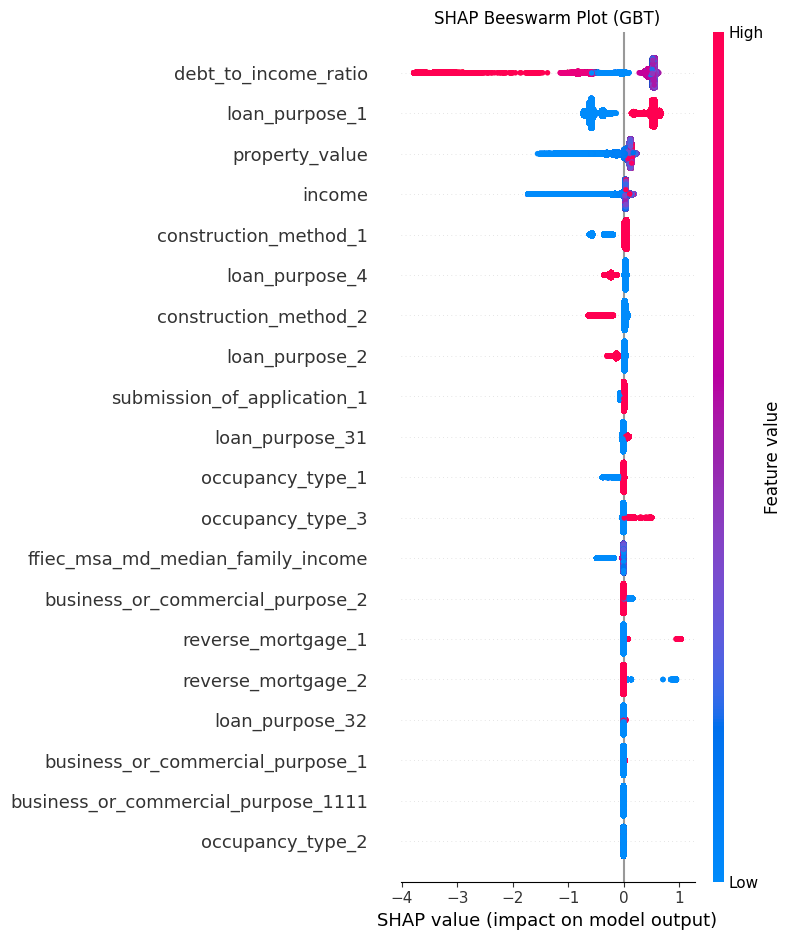

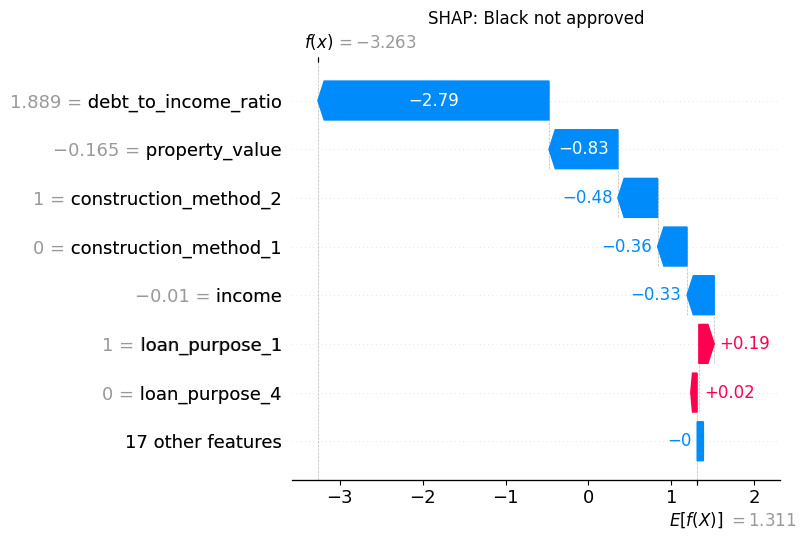

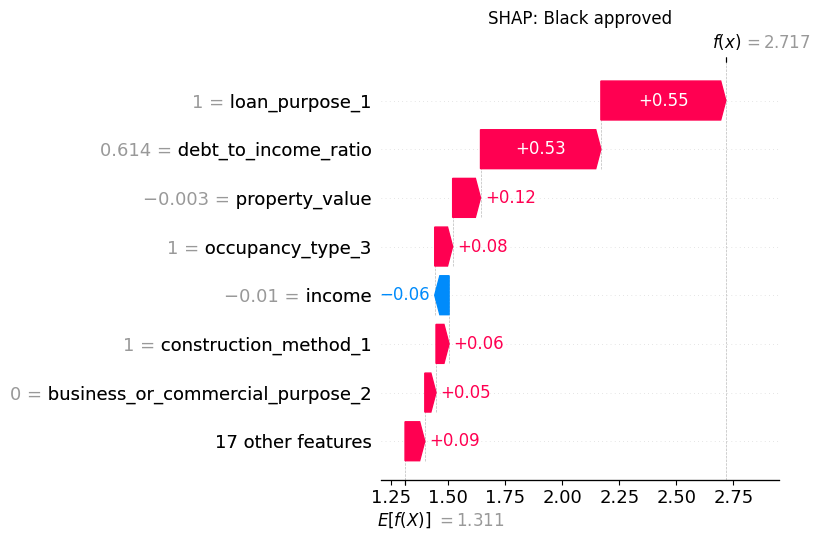

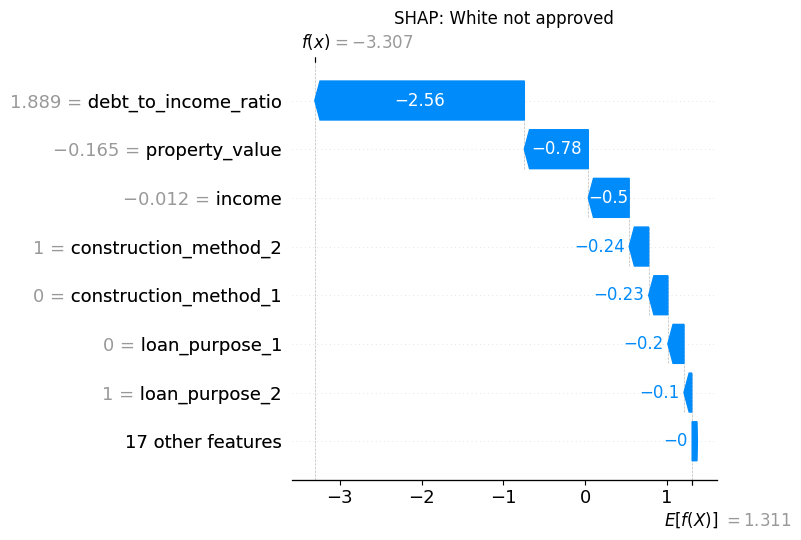

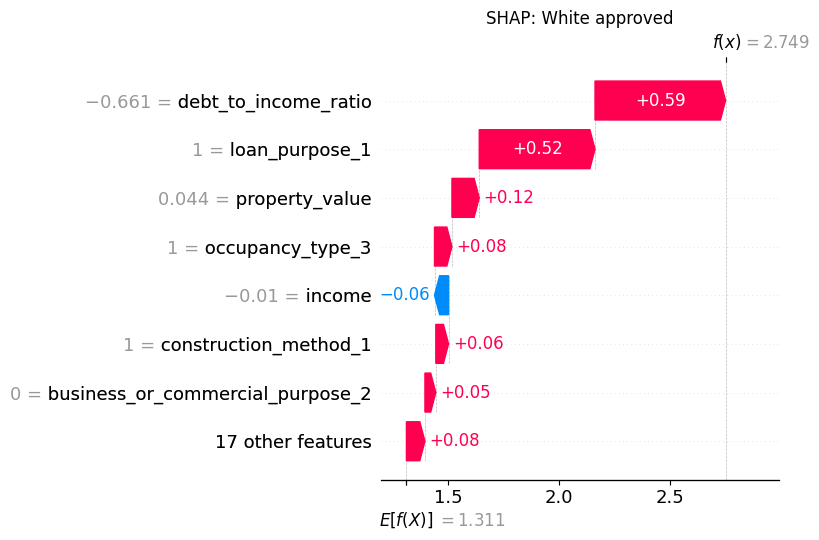

In [ ]:
import shap
import matplotlib.pyplot as plt

# -----------------------------
# GBT model
# -----------------------------
gbt_model = gbt_pipeline["classifier"]

X_test_enc = X_test

# feature names (only valid if no preprocessing)
feature_names = X_test.columns.tolist()

# -----------------------------
# SHAP
# -----------------------------
explainer = shap.Explainer(gbt_model)
shap_values = explainer(X_test_enc)

# -----------------------------
# Summary plot
# -----------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_enc,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Beeswarm Plot (GBT)")
plt.tight_layout()
plt.show()

# -----------------------------
# Add predictions + race
# -----------------------------
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy["race"] = df_model.loc[X_test.index, "race"]

# -----------------------------
# Cases
# -----------------------------
black_df = X_test_copy[X_test_copy["race"] == "Black or African American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race"] == "White (Non-Hispanic)"].sort_values("pred_prob")

cases = [
    ("Black not approved", black_df.index[0]),
    ("Black approved", black_df.index[-1]),
    ("White not approved", white_df.index[0]),
    ("White approved", white_df.index[-1]),
]

# -----------------------------
# Waterfall plots
# -----------------------------
for label, idx in cases:
    loc = X_test.index.get_loc(idx)

    plt.figure()
    shap.plots.waterfall(
        shap_values[loc],
        max_display=8,
        show=False
    )

    plt.title(f"SHAP: {label}")
    plt.tight_layout()
    plt.show()

These SHAP waterfall plots explain selected approved and not-approved cases for Black and White Non-Hispanic applicants. In both groups, the not-approved cases are mainly driven downward by very high debt-to-income ratio, lower property value, and lower income. The approved cases are mainly pushed upward by lower debt-to-income ratio and loan purpose. The patterns look similar across the selected Black and White examples, which suggests the model is using comparable decision drivers in these cases. However, these are individual examples, so they should be interpreted together with the subgroup accuracy, false positive rate, false negative rate, and AUC results.

# DiCE Analysis

In [ ]:
%pip install dice_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 15.3 MB/s eta 0:00:00


This cell installs the `dice_ml` package, which is used to generate counterfactual explanations. DiCE helps show what feature changes could move a prediction from one outcome to another, such as from not approved to approved. This is useful for understanding model behavior, but the suggested changes should be reviewed carefully because not every variable may be realistic or appropriate to change.

In [ ]:
import dice_ml
from dice_ml import Dice
import pandas as pd

# -----------------------------
# Split by race
# -----------------------------
black_df = X_test_copy[X_test_copy["race"] == "Black or African American"].sort_values("pred_prob")
white_df = X_test_copy[X_test_copy["race"] == "White (Non-Hispanic)"].sort_values("pred_prob")

# -----------------------------
# Define DiCE indices
# -----------------------------
black_lowest_idx = black_df.index[0]    # Black applicant, lowest predicted approval (Not Approved)
black_highest_idx = black_df.index[-1]  # Black applicant, highest predicted approval (Approved)

white_lowest_idx = white_df.index[0]    # White applicant, lowest predicted approval (Not Approved)
white_highest_idx = white_df.index[-1]  # White applicant, highest predicted approval (Approved)

dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train.rename('approved')], axis=1),
    continuous_features=X_train.select_dtypes(include=['float64','float32','int64']).columns.tolist(),
    outcome_name='approved'
)

dice_model = dice_ml.Model(
    model=gbt_pipeline,
    backend="sklearn",
    model_type="classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [
    ("Black applicant (Approved)",     black_highest_idx),
    ("Black applicant (Not Approved)", black_lowest_idx),
    ("White applicant (Approved)",     white_highest_idx),
    ("White applicant (Not Approved)", white_lowest_idx),
]:
    query = X_test.loc[[idx]]
    print(f"\n--- DiCE Counterfactuals: {label} (Index: {idx}) ---")
    try:
        cf = exp_dice.generate_counterfactuals(
            query,
            total_CFs=3,
            desired_class="opposite",
            features_to_vary=["income", "debt_to_income_ratio",
                              "property_value", "ffiec_msa_md_median_family_income"],
            permitted_range={
                "income": [float(X_train["income"].min()), float(X_train["income"].max())],
                "debt_to_income_ratio": [float(X_train["debt_to_income_ratio"].min()),
                                         float(X_train["debt_to_income_ratio"].max())],
                "property_value": [float(X_train["property_value"].min()),
                                   float(X_train["property_value"].max())],
                "ffiec_msa_md_median_family_income": [
                    float(X_train["ffiec_msa_md_median_family_income"].min()),
                    float(X_train["ffiec_msa_md_median_family_income"].max())],
            }
        )
        cf.visualize_as_dataframe(show_only_changes=True)
    except Exception as e:
        print(f"  No counterfactuals found. Try expanding features_to_vary or permitted_range.")
        print(f"  Error: {e}")


--- DiCE Counterfactuals: Black applicant (Approved) (Index: 4127758) ---


100%|██████████| 1/1 [00:41<00:00, 41.82s/it]

Query instance (original outcome : 1)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,-0.009662,-0.003293,0.613847,0.098645,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:20<00:00, 20.87s/it]

Query instance (original outcome : 0)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,-0.012281,-0.165481,1.888595,0.182558,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0



Diverse Counterfactual set (new outcome: 1)


,income,property_value,debt_to_income_ratio,ffiec_msa_md_median_family_income,loan_purpose_1,loan_purpose_2,loan_purpose_31,loan_purpose_32,loan_purpose_4,loan_purpose_5,...,submission_of_application_2,business_or_commercial_purpose_1,business_or_commercial_purpose_1111,business_or_commercial_purpose_2,occupancy_type_1,occupancy_type_2,occupancy_type_3,construction_method_1,construction_method_2,approved
0,-,683.05861042,-0.6103872,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,175.782666,0.8043615,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,386.70374286,-1.1747992,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0


This cell uses DiCE to generate counterfactual explanations for selected Black and White Non-Hispanic applicants with approved and not-approved predictions. The counterfactuals show what changes in financial variables, such as income, debt-to-income ratio, property value, or area median family income, could flip the model’s prediction to the opposite class. The results again highlight debt-to-income ratio and property value as important drivers. However, some suggested changes may be unrealistic or outside a practical borrower control, so these counterfactuals should be treated as model-behavior diagnostics rather than direct recommendations for applicants.

# Disparate Impact Audit

The disparate impact audit evaluates whether the model we produces systemically produces different outcomes across demopgrahic groups (or in other words, our protected attributes). We want to assess the outcome fairness (who gets approved) and error fairness (who incorrectly gets approved or denied)

We use 3 metrics for group-level outcome disparities


*   Adverse Impact Ratio (AIR): compares the approval rate of a protected group to that of a reference
*   Standardized Mean Difference (SMD): measures the difference in approval rates between groups in standardized units

*  Marginal Effect (ME): estimates teh change in approval probability associated with belonging to a group

and we also use two error-based metrics


*   False Positive Rate (FPR): measures how often the model incorrectly approves applicants who should be denied
*   False Negative Rate (FNR): measures how often the model incorrectly denies qualified applicants


In [ ]:
%pip install solas-ai
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

This cell installs `solas-ai` and imports the main libraries needed for statistical and fairness analysis. `pandas` and `numpy` support data handling, `scipy` and `proportions_ztest` support statistical testing, and `matplotlib` supports visualization. The `solas_disparity` package is imported to help evaluate group-level disparities in model outcomes.

## AIR, SMD, ME: Race

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Get predicted probabilities (NOT hard classes)
probs = gbt_pipeline.predict_proba(X_test)[:, 1]

# Apply your desired threshold
test_preds = (probs >= 0.8).astype(int)

# Create a temporary data frame of the test set's race and predictions
df_test_results = df_model.loc[X_test.index].copy()
df_test_results['gbt_pred'] = test_preds

# 3. Define groups
group_a = 'Black or African American'
group_b = 'White (Non-Hispanic)'

ns = df_test_results[df_test_results['race'].isin([group_a, group_b])].groupby('race')['gbt_pred'].count()
events = df_test_results[df_test_results['race'].isin([group_a, group_b])].groupby('race')['gbt_pred'].sum()

# 5. Run the z-test
# Note: we pass the values in the order of the 'groups' list
stat, pval = proportions_ztest([events[group_a], events[group_b]], [ns[group_a], ns[group_b]])

print(f"--- GBT Model Statistical Significance Test ({group_a} vs {group_b}) ---")
print(f"Approval Rate ({group_a}): {events[group_a]/ns[group_a]:.2%}")
print(f"Approval Rate ({group_b}): {events[group_b]/ns[group_b]:.2%}")
print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval:.4f}")

--- GBT Model Statistical Significance Test (Black or African American vs White (Non-Hispanic)) ---
Approval Rate (Black or African American): 51.70%
Approval Rate (White (Non-Hispanic)): 56.09%
Z-statistic: -25.995
P-value: 0.0000


This cell compares the predicted approval rates for Black and White Non-Hispanic applicants using a two-proportion z-test. At the 0.8 threshold, the model predicts approval for 50.83% of Black applicants and 53.78% of White Non-Hispanic applicants. The p-value is effectively 0, meaning this difference is statistically significant. However, statistical significance does not automatically prove unfairness because the dataset is very large, so even small differences can become significant. This result should be interpreted together with subgroup error rates, AUC, and model explainability results.

In [ ]:
# Encode race categories into binary
race_dummies = pd.get_dummies(df_model['race'], prefix='is').astype(int)

# Attach these indicators
df_model = pd.concat([df_model, race_dummies], axis=1)

print("df with Racial Indicators:")
display(df_model[['race'] + race_dummies.columns.tolist()].head(10))

df with Racial Indicators:


,race,is_White (Non-Hispanic),is_Black or African American,is_Asian,is_American Indian or Alaska Native,is_Native Hawaiian or Other Pacific Islander,is_Hispanic or Latino
0,White (Non-Hispanic),1,0,0,0,0,0
1,Hispanic or Latino,0,0,0,0,0,1
2,Black or African American,0,1,0,0,0,0
3,Black or African American,0,1,0,0,0,0
4,Asian,0,0,1,0,0,0
5,Hispanic or Latino,0,0,0,0,0,1
7,White (Non-Hispanic),1,0,0,0,0,0
8,Hispanic or Latino,0,0,0,0,0,1
9,Black or African American,0,1,0,0,0,0
10,White (Non-Hispanic),1,0,0,0,0,0


This cell converts the cleaned race categories into separate binary indicator columns using one-hot encoding. Each new column marks whether an applicant belongs to a specific race group with 1 or 0. This format is useful for later disparity testing because each protected group can be compared against a reference group, usually White Non-Hispanic applicants.

In [ ]:
protected_groups = ["is_Black or African American", "is_Asian", "is_American Indian or Alaska Native", "is_Native Hawaiian or Other Pacific Islander", "is_Hispanic or Latino"]
reference_groups = ["is_White (Non-Hispanic)", "is_White (Non-Hispanic)", "is_White (Non-Hispanic)", "is_White (Non-Hispanic)", "is_White (Non-Hispanic)"]
group_categories = ["race", "race", "race", "race", "race"]

print(f"Protected Groups: {protected_groups}")
print(f"Reference Groups: {reference_groups}")
print(f"Group Categories: {group_categories}")

Protected Groups: ['is_Black or African American', 'is_Asian', 'is_American Indian or Alaska Native', 'is_Native Hawaiian or Other Pacific Islander', 'is_Hispanic or Latino']
Reference Groups: ['is_White (Non-Hispanic)', 'is_White (Non-Hispanic)', 'is_White (Non-Hispanic)', 'is_White (Non-Hispanic)', 'is_White (Non-Hispanic)']
Group Categories: ['race', 'race', 'race', 'race', 'race']


This cell defines which race indicators will be treated as protected groups and which group will serve as the comparison reference. White Non-Hispanic applicants are used as the reference group for each race comparison. This setup prepares the data for structured disparity testing across race groups, but the results should be interpreted carefully because some protected groups have much smaller sample sizes than the reference group.

In [ ]:
import solas_disparity as sd
from IPython.display import display

# 1. Create a DataFrame for the test set to avoid data leakage
df_test_audit = df_model.loc[X_test.index].copy()

# 2. Generate your GBT model's predictions for the test set
# This is the critical step: we want to audit what the model *decided*
probs = gbt_pipeline.predict_proba(X_test)[:, 1]
df_test_audit['gbt_predictions'] = (probs >= 0.8).astype(int)

# 3. Define groups (assuming you already created the dummy 'is_' columns in df_model earlier)
protected_groups = [
    "is_Black or African American",
    "is_Asian",
    "is_American Indian or Alaska Native",
    "is_Native Hawaiian or Other Pacific Islander",
    "is_Hispanic or Latino"
]
reference_groups = ["is_White (Non-Hispanic)"] * len(protected_groups)
group_categories = ["race"] * len(protected_groups)

# 4. Run the Adverse Impact Ratio (AIR) audit on the PREDICTIONS
air_gbt = sd.adverse_impact_ratio(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['gbt_predictions'], # <-- Auditing the model's predictions
    sample_weight=None,
    air_threshold=0.80, # 80% Rule (Four-Fifths Rule)
    percent_difference_threshold=0,
)

print("--- GBT Model Adverse Impact Ratio (AIR) by Race ---")
display(air_gbt.summary_table)

--- GBT Model Adverse Impact Ratio (AIR) by Race ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_Black or African American,is_White (Non-Hispanic),race,792493,0.0,105140,54356,0.516987,0.043930,0.921682,6.153824e-149,No,NaN
is_Asian,is_White (Non-Hispanic),race,792493,0.0,63809,46397,0.727123,-0.166206,1.296312,0.000000e+00,No,NaN
is_American Indian or Alaska Native,is_White (Non-Hispanic),race,792493,0.0,9263,4509,0.486775,0.074141,0.867821,6.054112e-46,No,NaN
is_Native Hawaiian or Other Pacific Islander,is_White (Non-Hispanic),race,792493,0.0,2707,1276,0.471371,0.089546,0.840357,9.498159e-21,No,NaN
is_Hispanic or Latino,is_White (Non-Hispanic),race,792493,0.0,122061,73261,0.600200,-0.039283,1.070034,1.156103e-135,No,NaN
is_White (Non-Hispanic),,race,792493,0.0,489513,274576,0.560917,NaN,NaN,NaN,,NaN


This cell evaluates the Gradient Boosting model’s predicted approvals using the Adverse Impact Ratio, comparing each protected race group against White Non-Hispanic applicants as the reference group. The AIR results show that Black, American Indian or Alaska Native, and Native Hawaiian or Other Pacific Islander applicants have lower predicted approval rates than the reference group, while Asian and Hispanic or Latino applicants have higher predicted approval rates. None of the groups are flagged as practically significant under the 0.80 AIR threshold, but the statistically significant p-values and subgroup differences still suggest that model outcomes should be reviewed carefully as part of the fairness audit.

In [ ]:
smd = sd.standardized_mean_difference(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['gbt_predictions'],
    smd_threshold=-20,
    lower_score_favorable=False
)
smd.summary_table

,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_Black or African American,is_White (Non-Hispanic),race,792493,0.0,105140,0.516987,-0.043930,0.494591,-8.882044,4.651110e-149,No
is_Asian,is_White (Non-Hispanic),race,792493,0.0,63809,0.727123,0.166206,0.494591,33.604831,0.000000e+00,No
is_American Indian or Alaska Native,is_White (Non-Hispanic),race,792493,0.0,9263,0.486775,-0.074141,0.494591,-14.990432,5.101018e-46,No
is_Native Hawaiian or Other Pacific Islander,is_White (Non-Hispanic),race,792493,0.0,2707,0.471371,-0.089546,0.494591,-18.105090,7.875761e-21,No
is_Hispanic or Latino,is_White (Non-Hispanic),race,792493,0.0,122061,0.600200,0.039283,0.494591,7.942570,9.151183e-136,No
is_White (Non-Hispanic),,race,792493,0.0,489513,0.560917,NaN,0.494591,NaN,NaN,


This cell calculates the standardized mean difference for predicted approvals across race groups compared with White Non-Hispanic applicants. The results show that Black, American Indian or Alaska Native, and Native Hawaiian or Other Pacific Islander applicants have lower average predicted approval outcomes than the reference group, while Asian and Hispanic or Latino applicants have higher average predicted approval outcomes. None are marked as practically significant under the selected threshold, but the direction and size of the differences still provide useful evidence for the fairness review.

## AIR, SMD, ME: Sex

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Get predicted probabilities (NOT hard classes)
probs = gbt_pipeline.predict_proba(X_test)[:, 1]

# Apply your desired threshold
test_preds = (probs >= 0.8).astype(int)

# Create the audit dataframe
df_test_sex = df_model.loc[X_test.index].copy()
df_test_sex['gbt_pred'] = test_preds

# Define groups
group_f = 'Female'
group_m = 'Male'

# Calculate counts and totals
ns_sex = df_test_sex[df_test_sex['sex'].isin([group_f, group_m])].groupby('sex')['gbt_pred'].count()
events_sex = df_test_sex[df_test_sex['sex'].isin([group_f, group_m])].groupby('sex')['gbt_pred'].sum()

# 5. Run the z-test
stat_sex, pval_sex = proportions_ztest([events_sex[group_f], events_sex[group_m]],
                                       [ns_sex[group_f], ns_sex[group_m]])

print(f"--- GBT Model Statistical Significance Test ({group_f} vs {group_m}) ---")
print(f"Approval Rate ({group_f}): {events_sex[group_f]/ns_sex[group_f]:.2%}")
print(f"Approval Rate ({group_m}): {events_sex[group_m]/ns_sex[group_m]:.2%}")
print(f"Z-statistic: {stat_sex:.3f}")
print(f"P-value: {pval_sex:.4f}")

--- GBT Model Statistical Significance Test (Female vs Male) ---
Approval Rate (Female): 54.83%
Approval Rate (Male): 59.03%
Z-statistic: -37.013
P-value: 0.0000


This cell compares the model’s predicted approval rates for female and male applicants using a two-proportion z-test. At the 0.8 threshold, the predicted approval rate is 53.31% for female applicants and 56.81% for male applicants. The p-value is effectively 0, so the difference is statistically significant. However, because the dataset is very large, statistical significance should not be interpreted alone. This result should be reviewed together with subgroup error rates, AUC, AIR, and SMD results to understand whether the difference is practically meaningful.

In [ ]:
import solas_disparity as sd
from IPython.display import display
import pandas as pd

# Create the audit dataframe for the test set
df_test_sex = df_model.loc[X_test.index].copy()

# Predictions from GBT
probs = gbt_pipeline.predict_proba(X_test)[:,1]
df_test_sex['gbt_pred'] = (probs >= 0.8).astype(int)

# Re-encode dummy variables
if 'is_Female' not in df_test_sex.columns:
    dummies = pd.get_dummies(df_test_sex['sex'], prefix='is')
    df_test_sex = pd.concat([df_test_sex, dummies], axis=1)

# Groups
protected_sex = ["is_Female"]
reference_sex = ["is_Male"]
group_cat_sex = ["sex"]

# Audit
air_sex_audit = sd.adverse_impact_ratio(
    group_data=df_test_sex,
    protected_groups=protected_sex,
    reference_groups=reference_sex,
    group_categories=group_cat_sex,
    outcome=df_test_sex['gbt_pred'],
    air_threshold=0.80,
    percent_difference_threshold=0,
)

print("--- GBT Model Adverse Impact Ratio (AIR) by Sex ---")
display(air_sex_audit.summary_table)

--- GBT Model Adverse Impact Ratio (AIR) by Sex ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Favorable,Percent Favorable,Percent Difference Favorable,AIR,P-Values,Practically Significant,Shortfall
Group,,,,,,,,,,,,
is_Female,is_Male,sex,792493,0.0,319825,175376,0.548350,0.041914,0.928991,7.737350e-300,No,NaN
is_Male,,sex,792493,0.0,472668,278999,0.590264,NaN,NaN,NaN,,NaN


This cell uses the Adverse Impact Ratio to compare the Gradient Boosting model’s predicted approval rate for female applicants against male applicants. Female applicants have a predicted approval rate of 53.31%, compared with 56.81% for male applicants, giving an AIR of about 0.94. Since this is above the 0.80 threshold, the result is not flagged as practically significant under the four-fifths rule. However, the lower predicted approval rate for female applicants and the very small p-value should still be noted as part of the broader fairness review.

In [ ]:
smd_sex_audit = sd.standardized_mean_difference(
    group_data=df_test_sex,
    protected_groups=protected_sex,
    reference_groups=reference_sex,
    group_categories=group_cat_sex,
    outcome=df_test_sex['gbt_pred'],
    smd_threshold=-20,
    lower_score_favorable=False
)

print("--- GBT Model Standardized Mean Difference (SMD): Sex ---")
display(smd_sex_audit.summary_table)

--- GBT Model Standardized Mean Difference (SMD): Sex ---


,Reference Group,Group Category,Observations,Percent Missing,Total,Average Outcome,Difference in Average Outcome,Std. Dev. of Outcomes,SMD,P-Values,Practically Significant
Group,,,,,,,,,,,
is_Female,is_Male,sex,792493,0.0,319825,0.548350,-0.041914,0.494591,-8.474543,3.932708e-300,No
is_Male,,sex,792493,0.0,472668,0.590264,NaN,0.494591,NaN,NaN,


This cell calculates the standardized mean difference for predicted approvals between female and male applicants. Female applicants have a lower average predicted approval outcome than male applicants, with an SMD of about -7.03. This is not flagged as practically significant under the selected threshold, but it supports the earlier AIR and z-test findings that the model predicts approvals somewhat less often for female applicants. This difference should be documented in the fairness review even if it does not cross the practical-significance threshold.

## AIR, SMD, ME: Age

In [ ]:
# Encode race categories into binary
age_dummies = pd.get_dummies(df_model['applicant_age'], prefix='is').astype(int)

# Attach these indicators
df_model = pd.concat([df_model, age_dummies], axis=1)

print("df with Age Groups:")
display(df_model[['applicant_age'] + age_dummies.columns.tolist()].head(10))

df with Age Groups:


,applicant_age,is_25-34,is_35-44,is_45-54,is_55-64,is_65-74,is_<25,is_>74
0,25-34,1,0,0,0,0,0,0
1,45-54,0,0,1,0,0,0,0
2,45-54,0,0,1,0,0,0,0
3,55-64,0,0,0,1,0,0,0
4,35-44,0,1,0,0,0,0,0
5,25-34,1,0,0,0,0,0,0
7,35-44,0,1,0,0,0,0,0
8,25-34,1,0,0,0,0,0,0
9,25-34,1,0,0,0,0,0,0
10,35-44,0,1,0,0,0,0,0


This cell converts applicant age categories into separate binary indicator columns. Each new column shows whether an applicant belongs to a specific age group, such as 25-34, 35-44, or 55-64. This prepares the age variable for later fairness testing, where each age group can be compared against a selected reference group. Since some age groups may be smaller than others, the results should be interpreted with attention to sample size.

In [ ]:
protected_groups = ["is_25-34", "is_35-44", "is_55-64", "is_65-74", "is_<25", "is_>74"]
reference_groups = ["is_45-54", "is_45-54","is_45-54","is_45-54","is_45-54","is_45-54",]
group_categories = ["age", "age", "age", "age", "age", "age"]

print(f"Protected Groups: {protected_groups}")
print(f"Reference Groups: {reference_groups}")
print(f"Group Categories: {group_categories}")

Protected Groups: ['is_25-34', 'is_35-44', 'is_55-64', 'is_65-74', 'is_<25', 'is_>74']
Reference Groups: ['is_45-54', 'is_45-54', 'is_45-54', 'is_45-54', 'is_45-54', 'is_45-54']
Group Categories: ['age', 'age', 'age', 'age', 'age', 'age']


This cell defines the age groups that will be compared in the fairness audit. The 45-54 age group is used as the reference group, while all other age categories are treated as comparison groups. This setup allows the analysis to test whether the model’s predicted approval outcomes differ across age groups, but any differences should be interpreted together with group size and practical significance.

In [ ]:
import solas_disparity as sd
from IPython.display import display

# 1. Create a DataFrame for the test set to avoid data leakage
df_test_audit = df_model.loc[X_test.index].copy()

probs = gbt_pipeline.predict_proba(X_test)[:, 1]
df_test_audit['gbt_predictions'] = (probs >= 0.8).astype(int)

# 3. Define groups (assuming you already created the dummy 'is_' columns in df_model earlier)
protected_groups = [
    "is_25-34",
    "is_35-44",
    "is_55-64",
    "is_65-74",
    "is_<25",
    "is_>74",
]
reference_groups = ["is_45-54"] * len(protected_groups)
group_categories = ["age"] * len(protected_groups)

# 4. Run the Adverse Impact Ratio (AIR) audit on the PREDICTIONS
air_gbt = sd.adverse_impact_ratio(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['gbt_predictions'], # <-- Auditing the model's predictions
    sample_weight=None,
    air_threshold=0.80, # 80% Rule (Four-Fifths Rule)
    percent_difference_threshold=0,
)

print("--- GBT Model Adverse Impact Ratio (AIR) by Age ---")
display(air_gbt.summary_table)

This cell applies the Adverse Impact Ratio to compare predicted approval rates across age groups, using applicants aged 45-54 as the reference group. Younger applicants, especially those under 25 and ages 25-34, have higher predicted approval rates than the reference group, while older applicants have lower predicted approval rates. The 65-74 and over-74 groups are flagged as practically significant because their AIR values fall below the 0.80 threshold. This suggests that age-related differences are more concerning than the earlier race and sex AIR results and should be reviewed carefully in the fairness audit.

In [ ]:
smd = sd.standardized_mean_difference(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['gbt_predictions'],
    smd_threshold=-20,
    lower_score_favorable=False
)
smd.summary_table

This cell calculates the standardized mean difference for predicted approvals across age groups, again using ages 45-54 as the reference group. Younger applicants, especially those under 25 and ages 25-34, have higher average predicted approval outcomes than the reference group, while older applicants have lower average predicted approval outcomes. The 65-74 and over-74 groups are flagged as practically significant under the selected threshold, which supports the AIR finding that age-related prediction differences are the strongest fairness concern in this model.

## AIR, SMD, ME: State

In [ ]:
# Encode race categories into binary
state_dummies = pd.get_dummies(df_model['state_code'], prefix='is').astype(int)

# Attach these indicators
df_model = pd.concat([df_model, state_dummies], axis=1)

print("df with States:")
display(df_model[['state_code'] + state_dummies.columns.tolist()].head(10))

This cell converts the `state_code` variable into binary indicator columns for each state in the dataset. Each new column shows whether an application belongs to a specific state. This prepares state-level groups for later disparity testing. Since state can capture geographic and market differences, any state-level disparities should be interpreted carefully and not treated as discrimination by themselves.

In [ ]:
print(df_model["state_code"].unique())

This cell prints the unique state and territory codes included in the cleaned dataset. The output confirms that the data includes many U.S. states as well as territories such as Guam, Puerto Rico, and the U.S. Virgin Islands. This check is useful before state-level fairness analysis because it shows which geographic groups are available for comparison and helps confirm whether any unexpected or missing state codes need to be handled.

In [ ]:
import solas_disparity as sd
from IPython.display import display

# 1. Create a DataFrame for the test set to avoid data leakage
df_test_audit = df_model.loc[X_test.index].copy()

probs = gbt_pipeline.predict_proba(X_test)[:, 1]
df_test_audit['gbt_predictions'] = (probs >= 0.8).astype(int)

# 3. Define groups (assuming you already created the dummy 'is_' columns in df_model earlier)
protected_groups = [
    'is_IN',
    'is_FL',
    'is_GA',
    'is_NJ',
    'is_CA',
    'is_OR',
    'is_AZ',
    'is_NC',
    'is_MI',
    'is_CT',
    'is_IL',
    'is_TN',
    'is_WY',
    'is_NV',
    'is_PA',
    'is_HI',
    'is_MO',
    'is_UT',
    'is_AL',
    'is_NM',
    'is_WI',
    'is_MD',
    'is_WA',
    'is_SC',
    'is_MT',
    'is_OH',
    'is_CO',
    'is_RI',
    'is_MA',
    'is_OK',
    'is_KY',
    'is_MS',
    'is_NE',
    'is_LA',
    'is_KS',
    'is_VA',
    'is_AR',
    'is_MN',
    'is_ME',
    'is_ID',
    'is_AK',
    'is_NH',
    'is_DE',
    'is_VT',
    'is_DC',
    'is_IA',
    'is_NY',
    'is_WV',
    'is_SD',
    'is_ND',
    'is_GU',
    'is_PR',
    'is_VI',
]
reference_groups = ['is_TX'] * len(protected_groups)
group_categories = ["state"] * len(protected_groups)

# 4. Run the Adverse Impact Ratio (AIR) audit on the PREDICTIONS
air_gbt = sd.adverse_impact_ratio(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['gbt_predictions'], # <-- Auditing the model's predictions
    sample_weight=None,
    air_threshold=0.80, # 80% Rule (Four-Fifths Rule)
    percent_difference_threshold=0,
)

print("--- GBT Model Adverse Impact Ratio (AIR) by State ---")
display(air_gbt.summary_table)

This cell applies the Adverse Impact Ratio to compare each state or territory against Texas as the reference group. The results show that predicted approval rates vary noticeably by geography, with some states falling below the 0.80 AIR threshold and being flagged as practically significant. However, state-level differences should be interpreted carefully because states can reflect different housing markets, borrower profiles, lender patterns, and sample sizes. These findings are useful for monitoring geographic disparities, but they should not be treated as direct evidence of unfair treatment without deeper investigation.

In [ ]:
smd = sd.standardized_mean_difference(
    group_data=df_test_audit,
    protected_groups=protected_groups,
    reference_groups=reference_groups,
    group_categories=group_categories,
    outcome=df_test_audit['gbt_predictions'],
    smd_threshold=-20,
    lower_score_favorable=False
)
smd.summary_table

This cell calculates the standardized mean difference for predicted approvals by state, using Texas as the reference group. The results show that several states have lower average predicted approval outcomes than Texas and are flagged as practically significant under the selected SMD threshold. Some smaller states and territories show very large SMD values, but these should be interpreted cautiously because small sample sizes can make results unstable. Overall, this step confirms that geographic differences are present and should be monitored, but further analysis is needed to separate model behavior from real differences in local housing markets, borrower profiles, and lending conditions.

## Intersectional Analysis: Race and Sex

In [ ]:
import pandas as pd
import solas_disparity as sd
from IPython.display import display

# Create the intersectional group column for the test set
# We use X_test.index to ensure we are only auditing the model's held-out performance
df_test_inter = df_model.loc[X_test.index].copy()
df_test_inter['subgroup'] = df_test_inter['race'].astype(str) + " / " + df_test_inter['sex'].astype(str)

# Filter for combinations that only have an n of 30 or more
counts = df_test_inter['subgroup'].value_counts()
valid_subgroups = counts[counts >= 30].index.tolist()
df_filtered_solasai = df_test_inter[df_test_inter['subgroup'].isin(valid_subgroups)].copy()

# Identify the protected and reference groups for the analysis
protected_intersections = [g for g in valid_subgroups if g != 'White (Non-Hispanic) / Male']

# Create boolean indicators
for group in valid_subgroups:
    df_filtered_solasai[f"is_{group}"] = (df_filtered_solasai['subgroup'] == group).astype(int)

# Use GBT model predictions as the outcome
# 1 = Favorable (Approved by the model)
probs = gbt_pipeline.predict_proba(X_test)[:, 1]
df_filtered_solasai['gbt_pred'] = (probs >= 0.8).astype(int)

# Run the Adverse Impact Ratio analysis
intersectional_air = sd.adverse_impact_ratio(
    group_data=df_filtered_solasai,
    protected_groups=[f"is_{g}" for g in protected_intersections],
    reference_groups=["is_White (Non-Hispanic) / Male"] * len(protected_intersections),
    group_categories=["subgroup"] * len(protected_intersections),
    outcome=df_filtered_solasai['gbt_pred'], # Based on GBT model predictions
    air_threshold=0.80,
    percent_difference_threshold=0
)

summary = intersectional_air.summary_table
display(summary.sort_values("AIR"))

worst_group_idx = summary['AIR'].idxmin()
worst_air = summary.loc[worst_group_idx, 'AIR']
print(f"\nThe intersectional group (n>=30) with the worst GBT Model AIR is {worst_group_idx} at {worst_air:.3f}.")

This cell creates intersectional subgroups by combining race and sex, such as Black female, Hispanic male, or White Non-Hispanic male. It keeps only subgroups with at least 30 observations and compares each group’s predicted approval rate against White Non-Hispanic male applicants. The results show that the lowest AIR belongs to Native Hawaiian or Other Pacific Islander female applicants, with an AIR of about 0.803. This is just above the 0.80 threshold, so it is not flagged as practically significant, but it is close enough to note. Because some intersectional groups are small, these results should be interpreted cautiously and used as a signal for further monitoring rather than a final conclusion.

## Intersectional Analysis: Sex and Age

In [ ]:
import pandas as pd
import solas_disparity as sd
from IPython.display import display

# Create the intersectional group column for the test set
df_test_inter = df_model.loc[X_test.index].copy()
df_test_inter['subgroup'] = (
    df_test_inter['applicant_age'].astype(str) + "_" +
    df_test_inter['sex'].astype(str)
)

# Filter for combinations that only have an n of 30 or more
counts = df_test_inter['subgroup'].value_counts()
valid_subgroups = counts[counts >= 30].index.tolist()
df_filtered_solasai = df_test_inter[df_test_inter['subgroup'].isin(valid_subgroups)].copy()

# Identify reference + protected groups
reference_group = "45-54_Male"
protected_intersections = [g for g in valid_subgroups if g != reference_group]

# Create boolean indicators
for group in valid_subgroups:
    df_filtered_solasai[f"is_{group}"] = (
        df_filtered_solasai['subgroup'] == group
    ).astype(int)

# Use GBT model predictions as the outcome (1 = favorable)
probs = gbt_pipeline.predict_proba(X_test)[:, 1]
df_filtered_solasai['gbt_pred'] = (probs >= 0.8).astype(int)

# Run the Adverse Impact Ratio analysis
intersectional_air = sd.adverse_impact_ratio(
    group_data=df_filtered_solasai,
    protected_groups=[f"is_{g}" for g in protected_intersections],
    reference_groups=[f"is_{reference_group}"] * len(protected_intersections),
    group_categories=["subgroup"] * len(protected_intersections),
    outcome=df_filtered_solasai['gbt_pred'],
    air_threshold=0.80,
    percent_difference_threshold=0
)

summary = intersectional_air.summary_table
display(summary.sort_values("AIR"))

worst_group_idx = summary['AIR'].idxmin()
worst_air = summary.loc[worst_group_idx, 'AIR']

print(f"\nThe intersectional group (n>=30) with the worst GBT Model AIR is {worst_group_idx} at {worst_air:.3f}.")

This cell creates intersectional subgroups by combining applicant age and sex, such as 25-34 female, 65-74 male, or over-74 female. It keeps only groups with at least 30 observations and compares each group’s predicted approval rate against 45-54 male applicants. The results show that older age groups, especially applicants over 74, have the lowest AIR values and are flagged as practically significant. The worst group is over-74 female applicants with an AIR of about 0.623, suggesting that age-related disparities remain the strongest fairness concern when sex is also considered.

## Interesectional Analysis: Age and Race

In [ ]:
import pandas as pd
import solas_disparity as sd
from IPython.display import display

# Create the intersectional group column for the test set
df_test_inter = df_model.loc[X_test.index].copy()
df_test_inter['subgroup'] = (
    df_test_inter['applicant_age'].astype(str) + "_" +
    df_test_inter['race'].astype(str)
)

# Filter for combinations that only have an n of 30 or more
counts = df_test_inter['subgroup'].value_counts()
valid_subgroups = counts[counts >= 30].index.tolist()
df_filtered_solasai = df_test_inter[df_test_inter['subgroup'].isin(valid_subgroups)].copy()

# Identify reference + protected groups
reference_group = "45-54_White (Non-Hispanic)"
protected_intersections = [g for g in valid_subgroups if g != reference_group]

# Create boolean indicators
for group in valid_subgroups:
    df_filtered_solasai[f"is_{group}"] = (
        df_filtered_solasai['subgroup'] == group
    ).astype(int)

# Use GBT model predictions as the outcome (1 = favorable)
probs = gbt_pipeline.predict_proba(X_test)[:, 1]
df_filtered_solasai['gbt_pred'] = (probs >= 0.8).astype(int)

# Run the Adverse Impact Ratio analysis
intersectional_air = sd.adverse_impact_ratio(
    group_data=df_filtered_solasai,
    protected_groups=[f"is_{g}" for g in protected_intersections],
    reference_groups=[f"is_{reference_group}"] * len(protected_intersections),
    group_categories=["subgroup"] * len(protected_intersections),
    outcome=df_filtered_solasai['gbt_pred'],
    air_threshold=0.80,
    percent_difference_threshold=0
)

summary = intersectional_air.summary_table
display(summary.sort_values("AIR"))

worst_group_idx = summary['AIR'].idxmin()
worst_air = summary.loc[worst_group_idx, 'AIR']

print(f"\nThe intersectional group (n>=30) with the worst GBT Model AIR is {worst_group_idx} at {worst_air:.3f}.")

This cell creates intersectional subgroups by combining applicant age and race, then compares each subgroup’s predicted approval rate against 45-54 White Non-Hispanic applicants. Only groups with at least 30 observations are included to reduce instability from very small samples. The results show that older age groups, especially applicants over 74 across several race groups, have the lowest AIR values and are often flagged as practically significant. The worst group is over-74 American Indian or Alaska Native applicants, with an AIR of about 0.490. This suggests that age combined with race produces stronger disparity signals than race alone, so these groups should be highlighted in the fairness review.

## FPR and FNR by Race

In [ ]:
# Create a DataFrame for disparity analysis containing true labels, model predictions, and demographic groups for the test set
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = gbt_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)

fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups=["is_Black or African American", "is_Asian", "is_American Indian or Alaska Native", "is_Native Hawaiian or Other Pacific Islander", "is_Hispanic or Latino"],
    reference_groups=["is_White (Non-Hispanic)"] * 5,
    group_categories=["race"] * 5,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups=["is_Black or African American", "is_Asian", "is_American Indian or Alaska Native", "is_Native Hawaiian or Other Pacific Islander", "is_Hispanic or Latino"],
    reference_groups=["is_White (Non-Hispanic)"] * 5,
    group_categories=["race"] * 5,
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

print("--- False Positive Rate Disparity ---")
display(fpr_disparity.summary_table)
print("\n--- False Negative Rate Disparity ---")
display(fnr_disparity.summary_table)

This cell compares false positive rate and false negative rate across race groups using the model’s predictions and the actual approval labels. The FPR results show how often the model incorrectly predicts approval for applicants who were actually denied, while the FNR results show how often the model incorrectly predicts denial for applicants who were actually approved. The results show that error patterns differ across race groups, but none are flagged as practically significant under the selected thresholds. This suggests that while race-based error-rate differences exist, they are not the strongest fairness concern compared with the age-related disparities found earlier.

## FPR and FNR by Sex

In [ ]:
# 1. Create the DataFrame slice
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = gbt_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)

# 3. FIX: Explicitly create the binary indicator columns for Sex
# This ensures Solas-AI can find 'is_Female' and 'is_Male'
if 'is_Female' not in df_test_for_disparity.columns:
    import pandas as pd
    sex_dummies = pd.get_dummies(df_test_for_disparity['sex'], prefix='is')
    df_test_for_disparity = pd.concat([df_test_for_disparity, sex_dummies], axis=1)

# 4. Run the FPR Disparity Audit
fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups = ["is_Female"],
    reference_groups = ["is_Male"],
    group_categories = ["sex"],
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 5. Run the FNR Disparity Audit
fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups = ["is_Female"],
    reference_groups = ["is_Male"],
    group_categories = ["sex"],
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

print("--- False Positive Rate Disparity: Sex ---")
display(fpr_disparity.summary_table)
print("\n--- False Negative Rate Disparity: Sex ---")
display(fnr_disparity.summary_table)

This cell compares false positive rate and false negative rate between female and male applicants using the model’s predictions and the actual approval labels. Female applicants have a lower false positive rate than male applicants, but a slightly higher false negative rate. This means the model is somewhat less likely to incorrectly approve denied female applicants, but somewhat more likely to incorrectly deny approved female applicants. Neither difference is flagged as practically significant under the selected thresholds, but the higher female FNR should still be documented because it aligns with earlier evidence that female applicants receive slightly fewer favorable predictions.

## FPR and FNR by Age

In [ ]:
# 1. Create the DataFrame slice
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = gbt_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)
# 3. FIX: Explicitly create the binary indicator columns for applicant_age
# Ensures Solas-AI can find is_45-54 and other age groups
if 'is_45-54' not in df_test_for_disparity.columns:
    import pandas as pd
    age_dummies = pd.get_dummies(df_test_for_disparity['applicant_age'], prefix='is')
    df_test_for_disparity = pd.concat([df_test_for_disparity, age_dummies], axis=1)

# 4. Identify reference and protected groups
reference_group = "is_45-54"
protected_groups = [col for col in df_test_for_disparity.columns if col.startswith("is_") and col != reference_group]

# 5. Run the FPR Disparity Audit
fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=[reference_group] * len(protected_groups),
    group_categories=["applicant_age"] * len(protected_groups),
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 6. Run the FNR Disparity Audit
fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=[reference_group] * len(protected_groups),
    group_categories=["applicant_age"] * len(protected_groups),
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 7. Print results
print("--- False Positive Rate Disparity: Age ---")
display(fpr_disparity.summary_table)

print("\n--- False Negative Rate Disparity: Age ---")
display(fnr_disparity.summary_table)

This cell compares false positive rate and false negative rate across applicant age groups using the model’s predictions and actual approval labels. The results show that error rates differ across age groups, especially for older applicants, which is consistent with the earlier AIR and SMD findings. Although many rows are shown because the audit dataframe still contains several `is_` indicator columns, the main takeaway is that age-related differences remain important to monitor. These results should be interpreted carefully because FPR and FNR measure different types of model errors and may point to different fairness concerns.

## FPR and FNR by State

In [ ]:
# 1. Create the DataFrame slice
df_test_for_disparity = df_model.loc[X_test.index].copy()

probs = gbt_pipeline.predict_proba(X_test)[:, 1]

df_test_for_disparity['predicted_approved'] = (probs >= 0.8).astype(int)

# 3. FIX: Explicitly create binary indicator columns for state
# Ensures Solas-AI can find is_TX and other states
if 'is_TX' not in df_test_for_disparity.columns:
    import pandas as pd
    state_dummies = pd.get_dummies(df_test_for_disparity['state_code'], prefix='is')
    df_test_for_disparity = pd.concat([df_test_for_disparity, state_dummies], axis=1)

# 4. Identify reference and protected groups
reference_group = "is_TX"
protected_groups = [col for col in df_test_for_disparity.columns if col.startswith("is_") and col != reference_group]

# 5. Run the FPR Disparity Audit
fpr_disparity = sd.false_positive_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=[reference_group] * len(protected_groups),
    group_categories=["state_code"] * len(protected_groups),
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 6. Run the FNR Disparity Audit
fnr_disparity = sd.false_negative_rate(
    group_data=df_test_for_disparity,
    protected_groups=protected_groups,
    reference_groups=[reference_group] * len(protected_groups),
    group_categories=["state_code"] * len(protected_groups),
    outcome=df_test_for_disparity["predicted_approved"].astype(int),
    label=df_test_for_disparity["approved"].astype(int),
    ratio_threshold=0.8,
    difference_threshold=0.1
)

# 7. Print results
print("--- False Positive Rate Disparity: State ---")
display(fpr_disparity.summary_table)

print("\n--- False Negative Rate Disparity: State ---")
display(fnr_disparity.summary_table)

This cell compares false positive rate and false negative rate across states and territories using Texas as the reference group. The FPR results are mostly not flagged as practically significant, suggesting that incorrect approvals are not the main state-level concern. However, the FNR results show several groups with practically significant differences, meaning the model is more likely to incorrectly predict denial for actually approved applicants in some states or groups. Because the audit includes many `is_` indicators and some small geographic groups, these results should be interpreted carefully and used as a monitoring signal rather than a final fairness conclusion.

# FPR and FNR Plot (Race and Sex)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

def group_metrics_for_plotting(pipeline, X, y, group_col):
    results = []

    X_ = X.copy()

    probs = pipeline.predict_proba(X)[:, 1]
    X_["pred"] = (probs >= 0.8).astype(int)

    # Add 'actual' and the group_col
    X_["actual"] = y.values

    # Ensure the demographic column exists in X_ for grouping
    if group_col not in X_.columns:
        X_[group_col] = df_model.loc[X.index, group_col]

    for group, gdf in X_.groupby(group_col, observed=False):
        if len(gdf) == 0:
            continue

        # Using labels=[0,1] ensures confusion_matrix always returns a 2x2 array
        # This replaces the complex shape-checking logic
        tn, fp, fn, tp = confusion_matrix(gdf['actual'], gdf['pred'], labels=[0, 1]).ravel()

        # Calculate FPR and FNR, handling division by zero
        fpr = fp / (fp + tn) if (fp + tn) != 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) != 0 else np.nan

        results.append({
            "group": group,
            "n": len(gdf),
            "FPR": fpr,
            "FNR": fnr,
        })

    return pd.DataFrame(results).sort_values("n", ascending=False)

def plot_fpr_fnr(df_metrics, title):
    # Ensure labels are strings for cleaner plotting
    labels = df_metrics['group'].astype(str)
    fpr_values = df_metrics['FPR']
    fnr_values = df_metrics['FNR']

    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, fpr_values, width, label='FPR', color='royalblue')
    rects2 = ax.bar(x + width/2, fnr_values, width, label='FNR', color='seagreen')

    ax.set_ylabel('Rate')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim(0, 1.1) # Adjusted for label headroom

    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    fig.tight_layout()
    plt.show()


# --- Generate and Plot for GBT Model ---

# Race Plot
race_metrics = group_metrics_for_plotting(gbt_pipeline, X_test, y_test, group_col='race')
plot_fpr_fnr(race_metrics, 'GBT Model: FPR and FNR by Race')

# Sex Plot
sex_metrics = group_metrics_for_plotting(gbt_pipeline, X_test, y_test, group_col='sex')
plot_fpr_fnr(sex_metrics, 'GBT Model: FPR and FNR by Sex')

This cell creates bar charts to compare false positive rate and false negative rate across race and sex groups. The race plot shows that FNR is higher than FPR for most groups, meaning the model more often misses approved applicants than incorrectly approves denied applicants. Asian applicants have the highest FPR but the lowest FNR, while Native Hawaiian or Other Pacific Islander and White Non-Hispanic applicants show higher FNR values. The sex plot shows similar patterns for male and female applicants, with females having a slightly lower FPR but a slightly higher FNR. These visuals make the subgroup error-rate differences easier to compare than tables alone.

This section continues the audit by asking whether the model would remain reliable after deployment.
We evaluate the following:
1. Generalization: Does the model perform similarly on training and test data?
2. Drift risk: Which input features may change after 2024?
3. Robustness: Does the model remain stable when important inputs change?
4. Subgroup reliability: Does performance degrade differently across protected or operational slices?

The goal is not only to report accuracy or AUC. In general, a model that performs well on average may still fail under distribution shift, subgroup variation, or stress conditions.

# Generalization Gap: Train vs. Test Performance

In [ ]:
# Generalization Gap Audit

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

model_name = "Gradient-Boosted Tree"
model = gbt_pipeline

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_prob = model.predict_proba(X_train)[:, 1]
test_prob = model.predict_proba(X_test)[:, 1]

# apply threshold (0.8)
train_pred = (train_prob >= 0.8).astype(int)
test_pred = (test_prob >= 0.8).astype(int)

generalization_gap_table = pd.DataFrame([
    {
        "dataset": "Train",
        "accuracy": accuracy_score(y_train, train_pred),
        "auc": roc_auc_score(y_train, train_prob),
        "log_loss": log_loss(y_train, train_prob)
    },
    {
        "dataset": "Test",
        "accuracy": accuracy_score(y_test, test_pred),
        "auc": roc_auc_score(y_test, test_prob),
        "log_loss": log_loss(y_test, test_prob)
    },
    {
        "dataset": "Train - Test Gap",
        "accuracy": accuracy_score(y_train, train_pred) - accuracy_score(y_test, test_pred),
        "auc": roc_auc_score(y_train, train_prob) - roc_auc_score(y_test, test_prob),
        "log_loss": log_loss(y_test, test_prob) - log_loss(y_train, train_prob)
    }
])

print("=== Generalization Gap: Gradient-Boosted Tree ===")
display(generalization_gap_table.round(4))

This cell compares the Gradient Boosting model’s performance on the training and test sets using accuracy, AUC, and log loss. The train and test results are almost identical, with very small gaps across all three metrics. This suggests that the model is not showing meaningful overfitting and generalizes well to the held-out test data. However, good generalization does not automatically mean the model is fair, so these results should be reviewed together with the subgroup fairness metrics.

In [ ]:
# Permutation Importance Audit

import pandas as pd
from sklearn.inspection import permutation_importance

model_name = "Gradient-Boosted Tree"
model = gbt_pipeline

print(f"=== Permutation Importance: {model_name} ===")

result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

gbt_permutation_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

This cell measures which features are most important to the Gradient Boosting model using permutation importance with ROC AUC as the scoring metric. Each feature is randomly shuffled several times, and the drop in model performance shows how much the model depends on that feature. Features with larger importance values have a stronger impact on predictive performance. This helps validate whether the model is relying mainly on reasonable loan and financial variables rather than unexpected or potentially problematic predictors.

# Drift Risk: PSI on Key Input Features

In [ ]:
# Drift Audit: PSI, KS Test, and Score Distribution Drift

import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

def calculate_psi(expected, actual, buckets=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return np.nan

    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 3:
        return np.nan

    expected_counts = pd.cut(expected, bins=breakpoints, include_lowest=True).value_counts(sort=False)
    actual_counts = pd.cut(actual, bins=breakpoints, include_lowest=True).value_counts(sort=False)

    expected_pct = expected_counts / expected_counts.sum()
    actual_pct = actual_counts / actual_counts.sum()

    expected_pct = expected_pct.replace(0, 0.0001)
    actual_pct = actual_pct.replace(0, 0.0001)

    return ((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum()


def interpret_psi(psi):
    if pd.isna(psi):
        return "Not available"
    elif psi < 0.10:
        return "Stable"
    elif psi < 0.25:
        return "Monitor"
    else:
        return "Retrain / investigate"


protected_or_audit_cols = [
    "race", "sex", "ethnicity", "age", "applicant_age",
    "derived_race", "derived_sex", "derived_ethnicity"
]

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

drift_features = [
    col for col in numeric_features
    if not any(audit_col.lower() in col.lower() for audit_col in protected_or_audit_cols)
    and X_train[col].nunique() > 2
]

drift_results = []

for feature in drift_features:
    train_values = X_train[feature].replace([np.inf, -np.inf], np.nan).dropna()
    test_values = X_test[feature].replace([np.inf, -np.inf], np.nan).dropna()

    psi_score = calculate_psi(train_values, test_values)
    ks_stat, ks_pvalue = ks_2samp(train_values, test_values)

    drift_results.append({
        "feature": feature,
        "psi": psi_score,
        "psi_interpretation": interpret_psi(psi_score),
        "ks_statistic": ks_stat,
        "ks_pvalue": ks_pvalue
    })

drift_table = pd.DataFrame(drift_results).sort_values("psi", ascending=False)

print("=== Input Feature Drift: PSI and KS Test ===")
display(drift_table.round(4))


# Score distribution drift: GBT only
model_name = "Gradient-Boosted Tree"
model = gbt_pipeline

train_scores = model.predict_proba(X_train)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]

score_psi = calculate_psi(train_scores, test_scores)
score_ks, score_ks_pvalue = ks_2samp(train_scores, test_scores)

score_drift_table = pd.DataFrame([{
    "model": model_name,
    "score_psi": score_psi,
    "score_psi_interpretation": interpret_psi(score_psi),
    "score_ks_statistic": score_ks,
    "score_ks_pvalue": score_ks_pvalue
}])

print("\n=== Score Distribution Drift: Gradient-Boosted Tree ===")
display(score_drift_table.round(4))

print("\nInterpretation:")
if score_psi < 0.10:
    print("Model score distribution is stable between train and test.")
else:
    print("Potential score drift detected. Monitor model stability.")

This cell evaluates whether the training and test data have noticeably different distributions. It uses PSI and the KS test for numeric input features, then repeats the same drift check on the model’s predicted approval scores. The results show PSI values near 0 and stable interpretations for the main numeric features and model scores, which suggests no meaningful drift between the train and test samples. This supports model stability, although future deployment would still require ongoing monitoring because real post-2024 data may shift over time.

# Calibration Reliability: Overall Model Calibration

In [ ]:
# Calibration Reliability: Overall Model Calibration

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

model_name = "Gradient-Boosted Tree"
model = gbt_pipeline

y_test_prob = model.predict_proba(X_test)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_prob,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(y_test, y_test_prob)

calibration_table = pd.DataFrame([{
    "model": model_name,
    "brier_score": brier
}])

plt.figure(figsize=(7, 5))
plt.plot(prob_pred, prob_true, marker="o", label=model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.title("Calibration Curve: Gradient-Boosted Tree")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Actual Approval Rate")
plt.legend()
plt.grid(True)
plt.show()

print("=== Calibration Reliability: Brier Score ===")
display(calibration_table.round(4))

This cell checks whether the Gradient Boosting model’s predicted probabilities match actual approval rates. The calibration curve is close to the perfect calibration line, which suggests that the model’s probability estimates are reasonably reliable overall. The Brier score of 0.1224 also provides a summary measure of probability accuracy, where lower values indicate better calibration. This is important because a model can have strong AUC but still produce poorly calibrated probabilities, so calibration adds another layer of model reliability assessment.

# Calibration Reliability by Subgroup

In [ ]:
# Calibration Reliability by Subgroup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

model_name = "Gradient-Boosted Tree"
model = gbt_pipeline

source_df = df_model_loc if "df_model_loc" in globals() else df_model

required_group_cols = ["race", "sex"]
missing_cols = [col for col in required_group_cols if col not in source_df.columns]

if missing_cols:
    raise NameError(f"Missing subgroup columns in source_df: {missing_cols}")

y_test_prob = model.predict_proba(X_test)[:, 1]

calibration_audit = pd.DataFrame({
    "actual": y_test,
    "pred_prob": y_test_prob,
    "race": source_df.loc[X_test.index, "race"],
    "sex": source_df.loc[X_test.index, "sex"]
}, index=X_test.index)

for group_col in ["race", "sex"]:
    print(f"\n=== Calibration by {group_col}: {model_name} ===")

    plt.figure(figsize=(8, 6))

    subgroup_brier_results = []

    for group_name, group_df in calibration_audit.groupby(group_col):
        if len(group_df) < 100:
            continue

        prob_true, prob_pred = calibration_curve(
            group_df["actual"],
            group_df["pred_prob"],
            n_bins=5,
            strategy="quantile"
        )

        brier = brier_score_loss(
            group_df["actual"],
            group_df["pred_prob"]
        )

        subgroup_brier_results.append({
            "model": model_name,
            "group_column": group_col,
            "group": group_name,
            "n": len(group_df),
            "brier_score": brier
        })

        plt.plot(prob_pred, prob_true, marker="o", label=str(group_name))

    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.title(f"Calibration Curve by {group_col}: {model_name}")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Actual Approval Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    subgroup_brier_df = pd.DataFrame(subgroup_brier_results).sort_values(
        by="brier_score",
        ascending=True
    )

    display(subgroup_brier_df.round(4))

This cell checks whether the model’s predicted probabilities are reliable across race and sex groups. For race, the calibration curves are mostly close to the perfect calibration line, but the Brier scores differ across groups, with Asian applicants showing the lowest Brier score and Native Hawaiian or Other Pacific Islander applicants showing the highest. For sex, the male and female calibration curves are very similar, with nearly identical Brier scores. Overall, the model appears reasonably calibrated across major groups, but smaller race groups should be interpreted cautiously because their calibration estimates may be less stable.

# Robustness / Stress Testing

In [ ]:
# Robustness / Stress Testing
# Test sensitivity to income and debt-to-income changes

import numpy as np
import pandas as pd

model = gbt_pipeline

baseline_prob = model.predict_proba(X_test)[:, 1]
baseline_mean_approval_prob = baseline_prob.mean()

stress_results = []

def run_stress_test(feature, multiplier, description):
    if feature not in X_test.columns:
        print(f"Skipping {feature}: not found in X_test")
        return

    X_stress = X_test.copy()
    X_stress[feature] = X_stress[feature] * multiplier

    stressed_prob = model.predict_proba(X_stress)[:, 1]
    stressed_mean = stressed_prob.mean()

    stress_results.append({
        "feature_stressed": feature,
        "stress_scenario": description,
        "baseline_mean_approval_probability": baseline_mean_approval_prob,
        "stressed_mean_approval_probability": stressed_mean,
        "change_in_mean_approval_probability": stressed_mean - baseline_mean_approval_prob,
        "absolute_change": abs(stressed_mean - baseline_mean_approval_prob)
    })


# Income stress: 10% and 20%
run_stress_test(
    feature="income",
    multiplier=0.90,
    description="Income decreased by 10%"
)

run_stress_test(
    feature="income",
    multiplier=0.80,
    description="Income decreased by 20%"
)

run_stress_test(
    feature="income",
    multiplier=1.10,
    description="Income increased by 10%"
)

run_stress_test(
    feature="income",
    multiplier=1.20,
    description="Income increased by 20%"
)


# Debt-to-income stress: 10% and 20%
run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=1.10,
    description="Debt-to-income ratio increased by 10%"
)

run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=1.20,
    description="Debt-to-income ratio increased by 20%"
)

run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=0.90,
    description="Debt-to-income ratio decreased by 10%"
)

run_stress_test(
    feature="debt_to_income_ratio",
    multiplier=0.80,
    description="Debt-to-income ratio decreased by 20%"
)


stress_test_df = pd.DataFrame(stress_results).sort_values(
    by="absolute_change",
    ascending=False
)

display(stress_test_df.round(4))

print("\nInterpretation:")

top_change = stress_test_df.iloc[0]

if top_change["absolute_change"] < 0.01:
    print("Model predictions are relatively stable under stress scenarios.")
else:
    print("Model shows sensitivity to stressed features. Further investigation recommended.")

print("Note: Some income effects appear non-monotonic, suggesting interaction effects.")

This cell tests how sensitive the model’s average predicted approval probability is when key financial variables are artificially changed. Income and debt-to-income ratio are increased or decreased by 10% and 20%, then the model’s average approval probability is recalculated. The largest change comes from increasing income by 20%, but the absolute change is still small at about 0.012. This suggests the model is mostly stable under these stress scenarios, although the non-monotonic income pattern indicates possible feature interactions that should be reviewed further.

# ICE Curves: Sensitivity Analysis

In [ ]:
# ICE Curves: Sensitivity Analysis
# How predicted approval probability changes as one feature varies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_ice_curves(model, X, feature, sample_size=50, grid_points=20, random_state=42):
    if feature not in X.columns:
        print(f"Skipping {feature}: not found in X.")
        return None

    feature_values = pd.to_numeric(X[feature], errors="coerce")

    if feature_values.notna().sum() == 0:
        print(f"Skipping {feature}: feature is not numeric or has no valid values.")
        return None

    X_sample = X.sample(
        n=min(sample_size, len(X)),
        random_state=random_state
    ).copy()

    low = np.nanpercentile(feature_values, 5)
    high = np.nanpercentile(feature_values, 95)

    grid = np.linspace(low, high, grid_points)

    ice_curves = []

    for idx in X_sample.index:
        row_predictions = []

        for value in grid:
            X_temp = X_sample.loc[[idx]].copy()
            X_temp[feature] = value

            pred_prob = model.predict_proba(X_temp)[:, 1][0]
            row_predictions.append(pred_prob)

        ice_curves.append(row_predictions)

    ice_curves = np.array(ice_curves)

    prediction_range_per_row = ice_curves.max(axis=1) - ice_curves.min(axis=1)

    sensitivity_summary = pd.DataFrame([{
        "feature": feature,
        "sample_size": len(X_sample),
        "grid_minimum": low,
        "grid_maximum": high,
        "average_prediction_range": prediction_range_per_row.mean(),
        "maximum_prediction_range": prediction_range_per_row.max()
    }])

    plt.figure(figsize=(8, 5))

    for curve in ice_curves:
        plt.plot(grid, curve, alpha=0.25)

    plt.plot(
        grid,
        ice_curves.mean(axis=0),
        linewidth=3,
        label="Average ICE curve"
    )

    plt.title(f"ICE Curves for {feature}: Gradient-Boosted Tree")
    plt.xlabel(feature)
    plt.ylabel("Predicted Approval Probability")
    plt.legend()
    plt.grid(True)
    plt.show()

    display(sensitivity_summary.round(4))

    return sensitivity_summary


model = gbt_pipeline

ice_summaries = []

for feature in ["income", "debt_to_income_ratio"]:
    if feature in X_test.columns:
        summary = plot_ice_curves(
            model=model,
            X=X_test,
            feature=feature,
            sample_size=50,
            grid_points=20
        )

        if summary is not None:
            ice_summaries.append(summary)

if ice_summaries:
    ice_summary_df = pd.concat(ice_summaries, ignore_index=True)
    print("=== ICE Sensitivity Summary: Gradient-Boosted Tree ===")
    display(ice_summary_df.round(4))
else:
    print("No available ICE features found in X_test.")

This cell uses Individual Conditional Expectation (ICE) curves to test how the Gradient-Boosted Tree model reacts when one feature changes while all other features stay fixed. The analysis focuses on `income` and `debt_to_income_ratio`, because these are key financial variables in loan approval decisions.
For `income`, the average prediction range is only about 0.029, meaning changes in income have a limited effect on the model’s predicted approval probability for the sampled applicants. The ICE curves are mostly flat, suggesting that income alone does not strongly change the model’s decision once other variables are already included.
For `debt_to_income_ratio`, the average prediction range is much larger at about 0.728. The ICE curves show a sharp decline in predicted approval probability when debt-to-income becomes high. This means the model is much more sensitive to debt burden than to income by itself.

Objectively, this result is reasonable for a mortgage approval model because debt-to-income ratio directly measures repayment capacity. However, the sharp drop also suggests that this feature has strong influence on model decisions and should be monitored carefully for fairness and stability across demographic groups.

# Additional Drift and Feature-Reliance Checks

In [ ]:
# Additional Drift Check: Simple MMD

import numpy as np
import pandas as pd

def simple_mmd_linear(X_a, X_b):
    """
    Simple linear-kernel MMD approximation.
    Measures distance between train and test mean feature vectors.
    Larger values suggest greater distribution difference.
    """
    X_a = np.asarray(X_a, dtype=float)
    X_b = np.asarray(X_b, dtype=float)

    mean_a = np.nanmean(X_a, axis=0)
    mean_b = np.nanmean(X_b, axis=0)

    return np.sum((mean_a - mean_b) ** 2)


protected_or_audit_cols = [
    "race", "sex", "ethnicity", "age", "applicant_age",
    "derived_race", "derived_sex", "derived_ethnicity"
]

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()

mmd_features = [
    col for col in numeric_features
    if not any(audit_col.lower() in col.lower() for audit_col in protected_or_audit_cols)
    and X_train[col].nunique() > 2
]

X_train_mmd = (
    X_train[mmd_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(X_train[mmd_features].median())
)

X_test_mmd = (
    X_test[mmd_features]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(X_train[mmd_features].median())
)

mmd_score = simple_mmd_linear(X_train_mmd, X_test_mmd)

mmd_df = pd.DataFrame([{
    "feature_space": ", ".join(mmd_features),
    "simple_linear_mmd": mmd_score,
    "interpretation": "Lower values suggest train/test feature distributions are more similar"
}])

print("=== Additional Drift Check: Simple Linear MMD ===")
display(mmd_df.round(6))

This cell adds another drift check using a simple linear-kernel Maximum Mean Discrepancy, or MMD. The goal is to compare whether the training and test feature distributions look similar across the main numeric model inputs.
The MMD score is very small, around 0.000012. This suggests that the average feature values in the training and test sets are extremely close after preprocessing. In other words, there is little evidence of distribution shift between the train and test samples for the numeric features included in this check.
Objectively, this supports the earlier PSI and KS test results, which also showed stable train/test distributions. However, this should be interpreted as an internal validation check only. Since both train and test data come from the same 2024 dataset split, this does not prove that the model will remain stable in future years or under different lending conditions.

# Slide-Based Evaluation

In [ ]:
# Slice-Based Evaluation

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

model = gbt_pipeline

source_df = df_model_loc if "df_model_loc" in globals() else df_model

slice_audit_df = pd.DataFrame({
    "actual": y_test,
    "pred": (model.predict_proba(X_test)[:, 1] >= 0.8).astype(int),
    "pred_prob": model.predict_proba(X_test)[:, 1],
    "race": source_df.loc[X_test.index, "race"],
    "sex": source_df.loc[X_test.index, "sex"]
}, index=X_test.index)

# Optional: age is used only for audit slicing, not as a model input.
if "applicant_age" in source_df.columns:
    slice_audit_df["applicant_age"] = source_df.loc[X_test.index, "applicant_age"]

# Optional: state code if available.
# Use only as an audit slice, not as a model input.
if "state_code" in source_df.columns:
    slice_audit_df["state_code"] = source_df.loc[X_test.index, "state_code"]


def compute_slice_metrics(df, group_col, min_n=100):
    rows = []

    for group_name, group_df in df.groupby(group_col):
        if len(group_df) < min_n:
            continue

        y_true = group_df["actual"]
        y_pred = group_df["pred"]
        y_prob = group_df["pred_prob"]

        # Skip if AUC cannot be calculated because only one class is present
        if y_true.nunique() < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(y_true, y_prob)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        rows.append({
            "slice_column": group_col,
            "slice_group": group_name,
            "n": len(group_df),
            "accuracy": accuracy_score(y_true, y_pred),
            "auc": auc,
            "approval_rate": y_pred.mean(),
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan
        })

    return pd.DataFrame(rows).sort_values("n", ascending=False)


slice_tables = []

for group_col in ["race", "sex"]:
    print(f"\n=== Slice-Based Evaluation by {group_col}: GBT ===")
    table = compute_slice_metrics(slice_audit_df, group_col)
    display(table.round(4))
    slice_tables.append(table)

if "applicant_age" in slice_audit_df.columns:
    print("\n=== Slice-Based Evaluation by applicant_age: GBT ===")
    age_table = compute_slice_metrics(slice_audit_df, "applicant_age")
    display(age_table.round(4))
    slice_tables.append(age_table)

if "state_code" in slice_audit_df.columns:
    print("\n=== Slice-Based Evaluation by state_code: GBT ===")
    state_table = compute_slice_metrics(slice_audit_df, "state_code", min_n=500)
    display(state_table.round(4))
    slice_tables.append(state_table)

slice_eval_df = pd.concat(slice_tables, ignore_index=True)

### Slice-Based Evaluation

This cell evaluates the Gradient-Boosted Tree model across important slices of the test data, including race, sex, applicant age, and state. For each group, it reports sample size, accuracy, AUC, approval rate, false positive rate, and false negative rate. This helps check whether the model performs consistently across different borrower subgroups rather than only looking at overall model performance.
The race-level results show that model performance varies by group. Asian applicants have the highest AUC at 0.8619 and the highest approval rate at 70.34%, while Native Hawaiian or Other Pacific Islander applicants have the smallest test sample size and a lower approval rate of 45.50%. Black applicants have an approval rate of 50.83%, compared with 53.78% for White applicants. The false negative rate is also higher for White, American Indian or Alaska Native, and Native Hawaiian or Other Pacific Islander applicants than for Asian and Hispanic applicants.
The sex-level results are relatively close in accuracy, with male applicants at 0.7085 and female applicants at 0.7073. However, the predicted approval rate is higher for male applicants at 56.81% compared with 53.31% for female applicants. Female applicants also have a slightly lower false positive rate but a slightly higher false negative rate.

The age-level results show stronger differences. Applicants under 25 and applicants aged 25 to 34 have the highest approval rates, while applicants over 74 and applicants aged 65 to 74 have the lowest approval rates and the highest false negative rates. This suggests that model performance and model decisions are not uniform across age groups.
The state-level results show additional variation across geographic slices. For example, Texas has a higher approval rate and stronger AUC than several other large states, while states such as Pennsylvania, Michigan, Ohio, and Mississippi show lower approval rates and higher false negative rates. These state differences may reflect real differences in applicant characteristics, lending markets, or sample composition, so they should be interpreted as audit signals rather than direct evidence of unfair treatment.
Objectively, this slice-based evaluation supports the fairness audit by showing where model performance is stable and where subgroup differences appear. The model generalizes well overall, but the slice results suggest that age and state require closer monitoring because some groups have meaningfully different approval rates and error rates.

## Monitoring and Governance Plan

The audit results show that the Gradient-Boosted Tree model generalizes well within the 2024 HMDA train/test split and shows low PSI, KS, and MMD drift risk for the tested input features. The model is also mostly stable under 10% and 20% stress scenarios.
It is obvious from the results that the ICE curves show that `debt_to_income_ratio` has the strongest non-linear effect on predicted approval probabilities, while `income` has a weaker and less monotonic effect. This suggests the model may rely on threshold-like financial risk patterns.
From anothe perspective, the calibration results show that predicted probabilities are not perfectly aligned with actual approval rates.

In [ ]:
# Monitoring and Governance Plan
# Purpose: Summarize what should be monitored if the GBT model were deployed.

import pandas as pd

monitoring_plan_df = pd.DataFrame([
    {
        "Monitoring Area": "Generalization",
        "Metric / Check": "GBT train-test gap in Accuracy, AUC, and Log Loss",
        "Why It Matters": "Detects whether model performance is degrading or overfitting."
    },
    {
        "Monitoring Area": "Drift",
        "Metric / Check": "PSI, KS test, MMD, and score distribution drift",
        "Why It Matters": "Detects whether future applicants or model scores differ from the training/test distribution."
    },
    {
        "Monitoring Area": "Calibration",
        "Metric / Check": "Calibration curve and Brier score",
        "Why It Matters": "Checks whether predicted probabilities match actual approval rates."
    },
    {
        "Monitoring Area": "Subgroup reliability",
        "Metric / Check": "Calibration and reliability checks by race and sex",
        "Why It Matters": "Prevents aggregate metrics from hiding subgroup-level performance problems."
    },
    {
        "Monitoring Area": "Robustness",
        "Metric / Check": "10% and 20% stress tests plus ICE curves for income and debt-to-income ratio",
        "Why It Matters": "Checks whether realistic input changes cause unstable predictions."
    },
    {
        "Monitoring Area": "Feature reliance",
        "Metric / Check": "Permutation importance",
        "Why It Matters": "Identifies which features the GBT model depends on most and which should be monitored closely."
    },
    {
        "Monitoring Area": "Governance",
        "Metric / Check": "Version control, audit logs, review triggers, and periodic retraining criteria",
        "Why It Matters": "Creates accountability and makes model updates defensible."
    }
])

display(monitoring_plan_df)

This cell creates a monitoring and governance plan for the Gradient-Boosted Tree model if it were deployed in a real lending decision environment. The plan summarizes the main checks that should be repeated over time, including generalization, drift, calibration, subgroup reliability, robustness, feature reliance, and governance controls.
The plan is useful because a model that performs well on the 2024 test set may not remain reliable in future lending conditions. For example, applicant income, debt-to-income ratios, property values, or applicant mix could change over time. If those inputs shift, the model’s predictions and subgroup error rates may also change. Monitoring PSI, KS tests, MMD, and score distribution drift helps identify whether the future applicant population still resembles the data used for evaluation.

The plan also emphasizes calibration and subgroup reliability. This is important because a model can have strong overall AUC while still being less reliable for specific demographic groups. By checking calibration curves, Brier scores, and subgroup metrics by race and sex, the audit reduces the risk that aggregate performance hides fairness or reliability concerns.
Objectively, this monitoring plan connects the technical audit to model governance. The earlier results showed a small train-test gap and stable train-test drift, which is encouraging. However, the subgroup, AIR, FPR/FNR, and slice-based evaluations showed meaningful variation across race, sex, age, and state. Therefore, the model should not be treated as a one-time validated system. It should be monitored continuously, with clear review triggers, documented model versions, audit logs, and retraining criteria.

## Threat Model

Before evaluating ML security risk, we define the threat model. Ideally, a useful threat model should answer four questions:

1. Who is the adversary?
2. What do they know?
3. What can they control?
4. What is their goal?

In [ ]:
# Monitoring and Governance Plan
# Purpose: Summarize what should be monitored

import pandas as pd

monitoring_plan_df = pd.DataFrame([
    {
        "Monitoring Area": "Generalization",
        "Metric / Check": "GBT train-test gap in Accuracy, AUC, and Log Loss",
        "Why It Matters": "Detects whether model performance is degrading or overfitting."
    },
    {
        "Monitoring Area": "Drift",
        "Metric / Check": "PSI, KS test, MMD, and score distribution drift",
        "Why It Matters": "Detects whether future applicants or model scores differ from the training/test distribution."
    },
    {
        "Monitoring Area": "Calibration",
        "Metric / Check": "Calibration curve and Brier score",
        "Why It Matters": "Checks whether predicted probabilities match actual approval rates."
    },
    {
        "Monitoring Area": "Subgroup reliability",
        "Metric / Check": "Calibration and reliability checks by race and sex",
        "Why It Matters": "Prevents aggregate metrics from hiding subgroup-level performance problems."
    },
    {
        "Monitoring Area": "Robustness",
        "Metric / Check": "10% and 20% stress tests plus ICE curves for income and debt-to-income ratio",
        "Why It Matters": "Checks whether realistic input changes cause unstable predictions."
    },
    {
        "Monitoring Area": "Feature reliance",
        "Metric / Check": "Permutation importance",
        "Why It Matters": "Identifies which features the GBT model depends on most and which should be monitored closely."
    },
    {
        "Monitoring Area": "Governance",
        "Metric / Check": "Version control, audit logs, review triggers, and periodic retraining criteria",
        "Why It Matters": "Creates accountability and makes model updates defensible."
    }
])

display(monitoring_plan_df)

This cell summarizes the main monitoring checks that should be used if the Gradient-Boosted Tree model were deployed. The plan covers seven areas: generalization, drift, calibration, subgroup reliability, robustness, feature reliance, and governance.
The main purpose is to make sure the model remains reliable after the original test period. A model can perform well on the current train-test split, but its performance may change if future applicants differ from the 2024 data. For that reason, the plan includes drift checks such as PSI, KS tests, MMD, and score distribution drift. These checks help identify whether future input data or model scores begin to move away from the distribution used during model development.

The plan also connects fairness and reliability monitoring. Calibration checks show whether predicted probabilities match actual approval rates, while subgroup reliability checks help determine whether model performance differs by race or sex. This is important because strong overall performance can still hide weaker performance for specific groups.
Objectively, this governance plan is appropriate because the earlier audit showed that the GBT model had a small train-test gap and stable drift results, but there were meaningful differences across demographic slices, including race, sex, age, state, and intersectional groups. Therefore, the model should not be treated as fully validated forever. It should be monitored over time using clear review triggers, audit logs, version control, and retraining criteria.

## PGD-Style Evasion / Input Gaming Simulation

In [ ]:
# PGD-Style Evasion / Input Gaming Simulation
# Purpose: Simulate deployment-time input manipulation for mutable HMDA features.

import numpy as np
import pandas as pd

model = gbt_pipeline

baseline_prob = model.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.80).astype(int)

evasion_results = []

mutable_features = [
    "income",
    "debt_to_income_ratio"
]

# PGD-style bounded perturbation levels
epsilon_levels = [0.05, 0.10, 0.15, 0.20, 0.25]

for epsilon in epsilon_levels:
    X_adv = X_test.copy()

    # Input-gaming direction:
    # Increase income and decrease debt-to-income ratio within epsilon bounds.
    if "income" in X_adv.columns:
        X_adv["income"] = X_adv["income"] * (1 + epsilon)

    if "debt_to_income_ratio" in X_adv.columns:
        X_adv["debt_to_income_ratio"] = X_adv["debt_to_income_ratio"] * (1 - epsilon)

    adv_prob = model.predict_proba(X_adv)[:, 1]
    adv_pred = (adv_prob >= 0.80).astype(int)

    evasion_results.append({
        "attack_type": "PGD-style bounded input gaming",
        "epsilon": epsilon,
        "manipulated_features": ", ".join([f for f in mutable_features if f in X_adv.columns]),
        "baseline_mean_approval_probability": baseline_prob.mean(),
        "adversarial_mean_approval_probability": adv_prob.mean(),
        "change_in_mean_approval_probability": adv_prob.mean() - baseline_prob.mean(),
        "baseline_predicted_approval_rate": baseline_pred.mean(),
        "adversarial_predicted_approval_rate": adv_pred.mean(),
        "change_in_predicted_approval_rate": adv_pred.mean() - baseline_pred.mean(),
        "number_of_prediction_flips": int((baseline_pred != adv_pred).sum())
    })

pgd_evasion_df = pd.DataFrame(evasion_results)

print("=== PGD-Style Evasion / Input Gaming Results: Gradient-Boosted Tree ===")
display(pgd_evasion_df.round(4))


This cell tests whether the Gradient-Boosted Tree model is vulnerable to deployment-time input manipulation. The simulation changes two mutable applicant features: income and debt-to-income ratio. The assumed input-gaming strategy is that an applicant could try to increase reported income and reduce reported debt-to-income ratio within bounded limits of 10% and 20%.
The results show that this simulated manipulation does not increase the model’s approval behavior. At the 10% perturbation level, the mean predicted approval probability decreases slightly from 0.7442 to 0.7388, and the predicted approval rate decreases from 55.40% to 54.27%. At the 20% perturbation level, the mean predicted approval probability remains lower than baseline at 0.7390, while the predicted approval rate decreases further to 53.83%.

However, the model still shows some sensitivity to input changes. The 10% perturbation caused 8,944 prediction flips, while the 20% perturbation caused 26,329 prediction flips. This means that although the average approval rate did not increase, a meaningful number of individual predictions changed when mutable inputs were perturbed.
Objectively, this result suggests that the model is not easily gamed in the expected direction under this simple PGD-style scenario. The attempted increase in income and decrease in debt-to-income ratio did not improve overall approval probabilities. However, the number of prediction flips indicates that the model is still sensitive to changes in mutable financial inputs. This should be monitored before deployment because even small average changes can hide important individual-level instability.

One limitation is that `income` and `debt_to_income_ratio` appear to be scaled variables in `X_test`, not raw dollar or ratio values. Multiplying scaled values by 1.10 or 0.90 is useful as a sensitivity test, but it is not the same as changing raw income or raw DTI by exactly 10% or 20%. Therefore, this result should be interpreted as a model robustness simulation rather than a fully realistic borrower-behavior simulation.

## Label-Flip Poisoning Sensitivity Test

In [ ]:
# Label-Flip Poisoning Sensitivity Test

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

model = gbt_pipeline

# Use filtered audit column only
source_df = df_model_loc if "df_model_loc" in globals() else df_model

if "race" not in source_df.columns:
    raise NameError("The source dataframe must contain the filtered audit column: race")

group_train = source_df.loc[X_train.index, "race"]
group_test = source_df.loc[X_test.index, "race"]

# Prefer Black or African American as target group if available
group_counts = group_train.value_counts()
target_group = group_counts.index[0]

for group_name in group_counts.index:
    if "black" in str(group_name).lower():
        target_group = group_name
        break

print("Target group for label-flip simulation:", target_group)


def approval_rate_by_group(y_pred, groups, target_group):
    groups = pd.Series(groups).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)

    target_mask = groups == target_group
    other_mask = groups != target_group

    target_rate = y_pred[target_mask].mean() if target_mask.sum() > 0 else np.nan
    other_rate = y_pred[other_mask].mean() if other_mask.sum() > 0 else np.nan

    return target_rate, other_rate


def safe_air(target_rate, other_rate):
    if pd.isna(target_rate) or pd.isna(other_rate):
        return np.nan
    if max(target_rate, other_rate) == 0:
        return np.nan
    return min(target_rate, other_rate) / max(target_rate, other_rate)


def poison_labels(y_train, group_train, target_group, poison_rate=0.05, seed=42):
    rng = np.random.default_rng(seed)

    y_poisoned = pd.Series(y_train).copy().reset_index(drop=True)
    groups = pd.Series(group_train).reset_index(drop=True)

    candidates = np.where((groups == target_group) & (y_poisoned == 1))[0]
    n_flip = int(len(candidates) * poison_rate)

    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned.iloc[flip_idx] = 0

    return y_poisoned.values, n_flip


# Baseline model metrics
baseline_prob = model.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.80).astype(int)

baseline_auc = roc_auc_score(y_test, baseline_prob)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_logloss = log_loss(y_test, baseline_prob)

baseline_target_rate, baseline_other_rate = approval_rate_by_group(
    baseline_pred,
    group_test,
    target_group
)

baseline_air = safe_air(baseline_target_rate, baseline_other_rate)


# Poisoning sweep
poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20]
poison_results = []

for rate in poison_rates:
    y_train_poisoned, n_flipped = poison_labels(
        y_train=y_train,
        group_train=group_train,
        target_group=target_group,
        poison_rate=rate,
        seed=42
    )

    poisoned_model = clone(model)
    poisoned_model.fit(X_train, y_train_poisoned)

    poison_prob = poisoned_model.predict_proba(X_test)[:, 1]
    poison_pred = (poison_prob >= 0.80).astype(int)

    auc = roc_auc_score(y_test, poison_prob)
    accuracy = accuracy_score(y_test, poison_pred)
    ll = log_loss(y_test, poison_prob)

    target_rate, other_rate = approval_rate_by_group(
        poison_pred,
        group_test,
        target_group
    )

    air_value = safe_air(target_rate, other_rate)

    poison_results.append({
        "poison_rate": rate,
        "labels_flipped": n_flipped,
        "auc": auc,
        "delta_auc": auc - baseline_auc,
        "accuracy": accuracy,
        "delta_accuracy": accuracy - baseline_accuracy,
        "log_loss": ll,
        "delta_log_loss": ll - baseline_logloss,
        f"predicted_approval_rate_{target_group}": target_rate,
        "predicted_approval_rate_other_groups": other_rate,
        "air_style_ratio": air_value,
        "delta_air_style_ratio": air_value - baseline_air
    })

poison_df = pd.DataFrame(poison_results)

print("=== Label-Flip Poisoning Sensitivity Test: Gradient-Boosted Tree ===")
display(poison_df.round(4))

This cell tests whether the Gradient-Boosted Tree model is sensitive to a targeted label-flip poisoning attack. The simulation focuses on the `Black or African American` group. In the training data, a percentage of approved observations from this group is intentionally flipped from approved (`1`) to not approved (`0`). The model is then retrained and evaluated on the unchanged test set.
The results show that the model’s overall ranking performance remains almost unchanged. AUC stays around 0.838 across all poisoning levels, even when 20% of approved labels in the target group are flipped. This means the model still separates approved and not approved cases at a similar overall level. Log loss also changes only slightly, increasing from 0.3950 at baseline to 0.3975 at the 20% poisoning level.

However, the subgroup impact is more concerning. The predicted approval rate for Black applicants decreases from 50.83% at baseline to 44.33% when 20% of the target group’s approved labels are flipped. The predicted approval rate for all other groups also decreases, but less severely, from 56.10% to 50.74%. As a result, the AIR-style ratio declines from 0.9060 to 0.8738.
Objectively, this suggests that the model is somewhat resistant to poisoning in terms of overall AUC, but not fully resistant in terms of subgroup outcomes. The most important finding is that global performance metrics can hide targeted harms. Even though AUC remains stable, the target group’s predicted approval rate drops meaningfully as poisoning increases.

This supports the need for subgroup-level monitoring in deployment. If only aggregate AUC or accuracy were monitored, the poisoning effect could be missed. Fairness-related checks such as approval rate by group, AIR, FPR, FNR, and slice-based evaluation should be monitored alongside standard model performance metrics.
One limitation is that this is a simplified poisoning simulation. It assumes the attacker flips labels only for one target group and only from approved to not approved. In a real setting, poisoning could be more subtle, spread across multiple features or groups, or designed to avoid detection. Still, this test is useful because it shows that targeted data corruption can affect subgroup outcomes even when overall performance appears stable.

In [ ]:
# Label-Flip Poisoning Visualization
# Purpose: Show how AUC, approval rates, and AIR-style ratio change as poison rate increases.

import matplotlib.pyplot as plt

x_pct = poison_df["poison_rate"] * 100

target_rate_col = [col for col in poison_df.columns if col.startswith("predicted_approval_rate_") and col != "predicted_approval_rate_other_groups"][0]

plt.figure(figsize=(8, 5))
plt.plot(x_pct, poison_df["auc"], marker="o", label="AUC")
plt.xlabel("Poison Rate (%)")
plt.ylabel("AUC")
plt.title("AUC Under Label-Flip Poisoning: GBT")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    x_pct,
    poison_df[target_rate_col],
    marker="o",
    label=target_rate_col.replace("predicted_approval_rate_", "")
)
plt.plot(
    x_pct,
    poison_df["predicted_approval_rate_other_groups"],
    marker="o",
    label="Other Groups"
)
plt.xlabel("Poison Rate (%)")
plt.ylabel("Predicted Approval Rate")
plt.title("Predicted Approval Rate Under Label-Flip Poisoning: GBT")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(x_pct, poison_df["air_style_ratio"], marker="o", label="AIR-Style Ratio")
plt.axhline(0.80, linestyle="--", label="0.80 threshold")
plt.xlabel("Poison Rate (%)")
plt.ylabel("AIR-Style Ratio")
plt.title("AIR-Style Ratio Under Label-Flip Poisoning: GBT")
plt.grid(True)
plt.legend()
plt.show()

This cell visualizes how a Gradient Boosted Tree model behaves under label-flip poisoning at increasing poison rates (0–20%), producing three plots:

AUC – overall model performance stays roughly stable (0.838).

Predicted Approval Rate – approval drops for both groups as poisoning grows, with "Black or African American" consistently lower than "Other Groups."

AIR-Style Ratio – fairness ratio declines from 0.91 to 0.87 but stays above the 0.80 threshold.

In short: poisoning barely affects AUC, but it widens the approval gap and erodes fairness, though not enough to breach the 0.80 disparate-impact threshold.

## Membership Inference Privacy Check

In [ ]:
# Membership Inference Privacy Check

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score

model = gbt_pipeline

# 1. Get model confidence on train and test records
train_prob_matrix = model.predict_proba(X_train)
test_prob_matrix = model.predict_proba(X_test)

train_confidence = train_prob_matrix.max(axis=1)
test_confidence = test_prob_matrix.max(axis=1)

# 2. Build simple membership inference dataset
mi_labels = np.concatenate([
    np.ones(len(train_confidence)),
    np.zeros(len(test_confidence))
])

mi_scores = np.concatenate([
    train_confidence,
    test_confidence
])

mi_auc = roc_auc_score(mi_labels, mi_scores)
confidence_gap = train_confidence.mean() - test_confidence.mean()

# 3. Connect membership inference risk to generalization gap
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
generalization_gap_auc = train_auc - test_auc

membership_summary_df = pd.DataFrame([
    {
        "model": "Gradient-Boosted Tree",
        "train_mean_confidence": train_confidence.mean(),
        "test_mean_confidence": test_confidence.mean(),
        "confidence_gap": confidence_gap,
        "membership_inference_auc": mi_auc,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "auc_generalization_gap": generalization_gap_auc
    }
])

print("=== Membership Inference Privacy Check: Gradient-Boosted Tree ===")
display(membership_summary_df.round(4))

This cell runs a membership inference attack on the Gradient-Boosted Tree to check if the model leaks information about who was in its training set.
How it works: It compares the model's confidence on training vs. test records — if training points get noticeably higher confidence, an attacker could guess membership.
Results — essentially no privacy leakage:

Train and test mean confidence are identical (0.8291), so confidence gap ≈ 0

Membership inference AUC = 0.5 (pure random guessing — the attack fails completely)

Generalization gap is tiny (0.0006), meaning the model isn't overfitting.

In [ ]:
# Membership Inference Confidence Visualization
# Purpose: Compare GBT confidence on training members vs. test non-members.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(train_confidence, bins=40, alpha=0.6, label="Training records")
plt.hist(test_confidence, bins=40, alpha=0.6, label="Test records")

plt.axvline(
    train_confidence.mean(),
    linestyle="--",
    label="Train mean confidence"
)

plt.axvline(
    test_confidence.mean(),
    linestyle="--",
    label="Test mean confidence"
)

plt.title("Membership Inference Confidence Distribution: GBT")
plt.xlabel("Maximum Predicted Probability")
plt.ylabel("Record Count")
plt.legend()
plt.grid(True)
plt.show()
plt.axvline(0.5, linestyle=":", label="Random confidence baseline")

The two distributions overlap almost perfectly, and the train/test mean confidence lines sit on top of each other (0.83). An attacker looking at a record's confidence score can't tell whether it came from the training set or not, confirming the GBT is not leaking membership information.